# Same Parameters, Different Connectivity — Pruning Robustness Experiment

**Research question:** Does the distribution of neural connections influence pruning robustness more than the total number of parameters?

> **Caveat:** with the hidden sizes below (256/256, 512/128, 128/512) the three networks do **not** have equal parameter counts (Balanced ≈269k, FrontLoaded ≈469k, BackLoaded ≈172k) — the 784-wide input layer means `784*h1` dominates, so a large `h1` always costs more than a large `h2`. An optional parameter-matched swap (300/109, 180/670) is provided further down if you want a strict "same parameters" comparison instead. Either way, report the actual counts printed in the cell below.


In [ ]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms

import networkx as nx

from scipy.stats import ttest_ind

from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)


cpu


In [ ]:
seed=42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False


In [ ]:
transform=transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )

])

trainset=torchvision.datasets.MNIST(

    root="./data",

    train=True,

    download=True,

    transform=transform

)

testset=torchvision.datasets.MNIST(

    root="./data",

    train=False,

    download=True,

    transform=transform

)


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.47MB/s]


In [ ]:
trainloader=torch.utils.data.DataLoader(

    trainset,

    batch_size=128,

    shuffle=True

)

testloader=torch.utils.data.DataLoader(

    testset,

    batch_size=256,

    shuffle=False

)


In [ ]:
class BalancedNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1=nn.Linear(784,256)

        self.fc2=nn.Linear(256,256)

        self.fc3=nn.Linear(256,10)

        self.relu=nn.ReLU()

    def forward(self,x):

        x=x.view(-1,784)

        x=self.relu(self.fc1(x))

        x=self.relu(self.fc2(x))

        x=self.fc3(x)

        return x


class FrontLoadedNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1=nn.Linear(784,512)

        self.fc2=nn.Linear(512,128)

        self.fc3=nn.Linear(128,10)

        self.relu=nn.ReLU()

    def forward(self,x):

        x=x.view(-1,784)

        x=self.relu(self.fc1(x))

        x=self.relu(self.fc2(x))

        x=self.fc3(x)

        return x


class BackLoadedNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1=nn.Linear(784,128)

        self.fc2=nn.Linear(128,512)

        self.fc3=nn.Linear(512,10)

        self.relu=nn.ReLU()

    def forward(self,x):

        x=x.view(-1,784)

        x=self.relu(self.fc1(x))

        x=self.relu(self.fc2(x))

        x=self.fc3(x)

        return x


In [ ]:
def count_parameters(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

models={

    "Balanced":BalancedNet(),

    "FrontLoaded":FrontLoadedNet(),

    "BackLoaded":BackLoadedNet()

}

for name,m in models.items():

    print(name,count_parameters(m))


Balanced 269322
FrontLoaded 468874
BackLoaded 171658


## 7b. Visualize Network Architectures

A simple layered diagram of each network's shape (784 input -> h1 -> h2 -> 10 output). Nodes per layer are capped for readability -- the input layer has 784 nodes, so only a representative subset is drawn, with the true layer size labelled underneath.


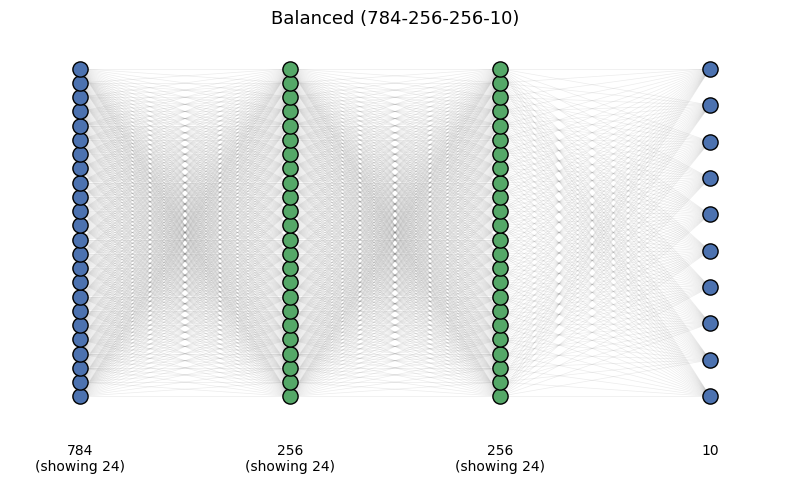

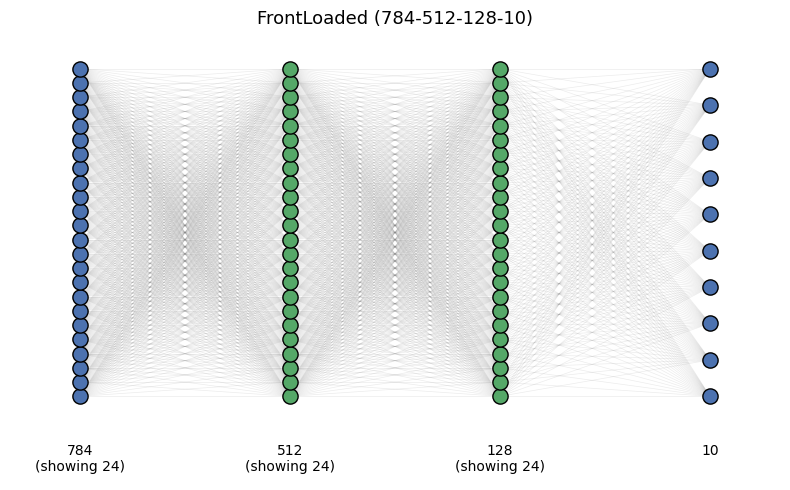

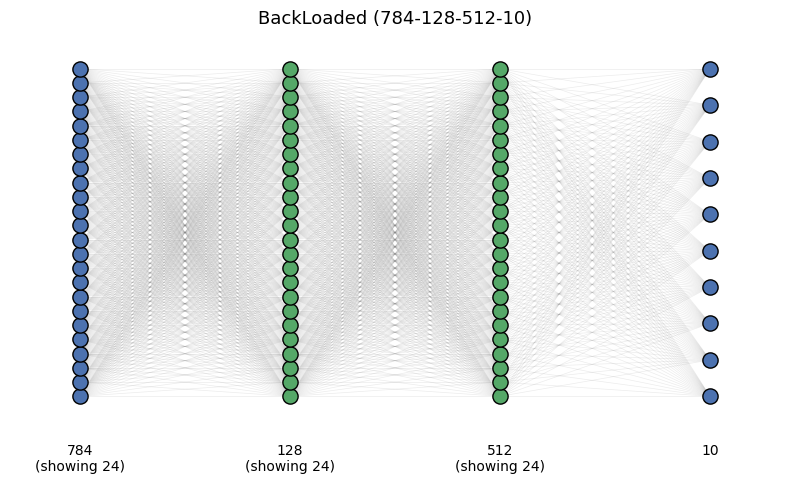

In [ ]:
import os
os.makedirs("results",exist_ok=True)

def draw_network_diagram(layer_sizes,title,max_nodes_per_layer=24):

    fig,ax=plt.subplots(figsize=(8,5))
    n_layers=len(layer_sizes)
    layer_x=np.linspace(0.05,0.95,n_layers)

    positions=[]
    for size in layer_sizes:
        shown=min(size,max_nodes_per_layer)
        ys=np.linspace(0.05,0.95,shown) if shown>1 else [0.5]
        positions.append(list(ys))

    for li in range(n_layers-1):
        for y1 in positions[li]:
            for y2 in positions[li+1]:
                ax.plot([layer_x[li],layer_x[li+1]],[y1,y2],
                        color="gray",alpha=0.15,linewidth=0.5,zorder=1)

    for li,ys in enumerate(positions):
        color="#4C72B0" if li in (0,n_layers-1) else "#55A868"
        for y in ys:
            ax.scatter(layer_x[li],y,s=120,color=color,edgecolor="black",zorder=2)

    for li,size in enumerate(layer_sizes):
        shown=min(size,max_nodes_per_layer)
        label=f"{size}" if size==shown else f"{size}\n(showing {shown})"
        ax.text(layer_x[li],-0.08,label,ha="center",va="top",fontsize=10)

    ax.set_xlim(-0.05,1.05)
    ax.set_ylim(-0.18,1.05)
    ax.axis("off")
    ax.set_title(title,fontsize=13)
    plt.tight_layout()
    safe_name=title.split(" ")[0]
    plt.savefig(f"results/architecture_{safe_name}.png",dpi=150)
    plt.show()


draw_network_diagram([784,256,256,10],"Balanced (784-256-256-10)")
draw_network_diagram([784,512,128,10],"FrontLoaded (784-512-128-10)")
draw_network_diagram([784,128,512,10],"BackLoaded (784-128-512-10)")


### Optional: parameter-matched hidden sizes

Uncomment the block below and re-run it (it overwrites `FrontLoadedNet`, `BackLoadedNet`, and `models`) if you want all three networks at ≈269k parameters instead of the original 512/128 and 128/512 shapes. Skip this cell entirely to keep your original architectures.


In [ ]:
# class FrontLoadedNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1=nn.Linear(784,300)
#         self.fc2=nn.Linear(300,109)
#         self.fc3=nn.Linear(109,10)
#         self.relu=nn.ReLU()
#     def forward(self,x):
#         x=x.view(-1,784)
#         x=self.relu(self.fc1(x))
#         x=self.relu(self.fc2(x))
#         x=self.fc3(x)
#         return x

# class BackLoadedNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.fc1=nn.Linear(784,180)
#         self.fc2=nn.Linear(180,670)
#         self.fc3=nn.Linear(670,10)
#         self.relu=nn.ReLU()
#     def forward(self,x):
#         x=x.view(-1,784)
#         x=self.relu(self.fc1(x))
#         x=self.relu(self.fc2(x))
#         x=self.fc3(x)
#         return x

# models={
#     "Balanced":BalancedNet(),
#     "FrontLoaded":FrontLoadedNet(),
#     "BackLoaded":BackLoadedNet()
# }
# for name,m in models.items():
#     print(name,count_parameters(m))


## 8. Train Models

In [ ]:
def train_model(model,trainloader,testloader,epochs=10,lr=0.001,verbose=True):

    model=model.to(device)

    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=lr)

    history={"train_loss":[],"train_acc":[],"test_loss":[],"test_acc":[]}

    for epoch in range(epochs):

        model.train()
        running_loss,correct,total=0.0,0,0

        for images,labels in trainloader:

            images,labels=images.to(device),labels.to(device)

            optimizer.zero_grad()
            outputs=model(images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()*images.size(0)
            _,predicted=outputs.max(1)
            correct+=predicted.eq(labels).sum().item()
            total+=labels.size(0)

        train_loss=running_loss/total
        train_acc=correct/total

        test_loss,test_acc=evaluate_model(model,testloader,criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if verbose:
            print(f"[{model.__class__.__name__}] epoch {epoch+1}/{epochs} "
                  f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                  f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}")

    return history


## 9. Evaluate

In [ ]:
def evaluate_model(model,loader,criterion=None):

    if criterion is None:
        criterion=nn.CrossEntropyLoss()

    model.eval()
    running_loss,correct,total=0.0,0,0

    with torch.no_grad():
        for images,labels in loader:

            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            loss=criterion(outputs,labels)

            running_loss+=loss.item()*images.size(0)
            _,predicted=outputs.max(1)
            correct+=predicted.eq(labels).sum().item()
            total+=labels.size(0)

    return running_loss/total,correct/total


def get_confusion_matrix(model,loader):

    model.eval()
    all_preds,all_labels=[],[]

    with torch.no_grad():
        for images,labels in loader:

            images=images.to(device)
            outputs=model(images)
            _,predicted=outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return confusion_matrix(all_labels,all_preds)


## 10. Graph Construction

Works for any of the three classes since they all expose `fc1`, `fc2`, `fc3`. Nodes are `(layer_name, index)`. An edge exists if the connecting weight is non-zero — after pruning (Section 14), pruned weights are exactly zero, so this automatically turns pruning into edge removal.


In [ ]:
def model_to_graph(model,weight_threshold=0.0):

    G=nx.DiGraph()

    layers=[
        ("fc1",model.fc1,"input","h1"),
        ("fc2",model.fc2,"h1","h2"),
        ("fc3",model.fc3,"h2","output"),
    ]

    for i in range(model.fc1.in_features):
        G.add_node(("input",i),layer="input")

    for layer_name,layer,in_name,out_name in layers:

        W=layer.weight.detach().cpu().numpy()
        out_features,in_features=W.shape

        for j in range(out_features):
            G.add_node((out_name,j),layer=out_name)

        for i in range(in_features):
            for j in range(out_features):
                w=W[j,i]
                if abs(w)>weight_threshold:
                    G.add_edge((in_name,i),(out_name,j),weight=float(w))

    return G


## 11. Graph Metrics

In [ ]:
def compute_graph_metrics(G):

    n_nodes=G.number_of_nodes()
    n_edges=G.number_of_edges()
    density=nx.density(G)

    degrees=[d for _,d in G.degree()]
    avg_degree=float(np.mean(degrees)) if degrees else 0.0

    UG=G.to_undirected()
    components=list(nx.connected_components(UG))
    n_components=len(components)
    largest_cc_size=max(len(c) for c in components) if components else 0
    largest_cc_fraction=largest_cc_size/n_nodes if n_nodes>0 else 0.0

    return {
        "n_nodes":n_nodes,
        "n_edges":n_edges,
        "density":density,
        "avg_degree":avg_degree,
        "n_connected_components":n_components,
        "largest_cc_size":largest_cc_size,
        "largest_cc_fraction":largest_cc_fraction,
    }


## 12. Spectral Analysis

`spectral_radius`: largest |eigenvalue| of the undirected adjacency matrix. `algebraic_connectivity` (Fiedler value): 2nd-smallest Laplacian eigenvalue, only well-defined for connected graphs — computed on the largest connected component if pruning has disconnected the graph.


In [ ]:
def compute_spectral_metrics(G):

    UG=G.to_undirected()

    A=nx.to_numpy_array(UG)
    eigvals_A=np.linalg.eigvals(A)
    spectral_radius=float(np.max(np.abs(eigvals_A)))

    if UG.number_of_nodes()>1 and nx.is_connected(UG):
        laplacian_eigvals=np.sort(nx.laplacian_spectrum(UG))
        algebraic_connectivity=float(laplacian_eigvals[1])
    else:
        components=list(nx.connected_components(UG))
        algebraic_connectivity=0.0
        if components:
            largest=max(components,key=len)
            sub=UG.subgraph(largest)
            if sub.number_of_nodes()>1:
                laplacian_eigvals=np.sort(nx.laplacian_spectrum(sub))
                algebraic_connectivity=float(laplacian_eigvals[1])

    return {
        "spectral_radius":spectral_radius,
        "algebraic_connectivity":algebraic_connectivity,
    }


## 13. Centrality

Betweenness is O(n*m) or worse, expensive for ~1000-1500 node graphs, so it's approximated with a random sample of source nodes (standard NetworkX technique for large graphs) — worth a line in your methodology/limitations.


In [ ]:
def compute_centrality_metrics(G,top_k=10,betweenness_sample=50):

    degree_centrality=nx.degree_centrality(G)

    try:
        eigenvector_centrality=nx.eigenvector_centrality_numpy(G.to_undirected())
    except Exception:
        eigenvector_centrality={n:0.0 for n in G.nodes()}

    k_sample=min(betweenness_sample,G.number_of_nodes())
    betweenness_centrality=nx.betweenness_centrality(G.to_undirected(),k=k_sample,seed=seed)

    top_degree=sorted(degree_centrality.items(),key=lambda x:-x[1])[:top_k]
    top_eigen=sorted(eigenvector_centrality.items(),key=lambda x:-x[1])[:top_k]
    top_betweenness=sorted(betweenness_centrality.items(),key=lambda x:-x[1])[:top_k]

    return {
        "degree_centrality":degree_centrality,
        "eigenvector_centrality":eigenvector_centrality,
        "betweenness_centrality":betweenness_centrality,
        "top_degree_nodes":top_degree,
        "top_eigenvector_nodes":top_eigen,
        "top_betweenness_nodes":top_betweenness,
    }


## 14. Pruning

Global unstructured L1 (magnitude) pruning across fc1+fc2+fc3 jointly, following Han et al. (2015). Applied to a deep copy so the original trained weights survive re-pruning at every level.


In [ ]:
pruning_levels=[0.0,0.2,0.4,0.6,0.8,0.9]

def apply_global_pruning(model,amount):

    pruned_model=copy.deepcopy(model)

    parameters_to_prune=[
        (pruned_model.fc1,"weight"),
        (pruned_model.fc2,"weight"),
        (pruned_model.fc3,"weight"),
    ]

    if amount>0:
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=amount,
        )
        for module,param_name in parameters_to_prune:
            prune.remove(module,param_name)

    return pruned_model


def measure_actual_sparsity(model):

    layer_sparsity={}
    total_zeros,total_elements=0,0

    for name,module in [("fc1",model.fc1),("fc2",model.fc2),("fc3",model.fc3)]:
        w=module.weight.detach()
        zeros=(w==0).sum().item()
        elements=w.numel()
        layer_sparsity[f"sparsity_{name}"]=zeros/elements
        total_zeros+=zeros
        total_elements+=elements

    layer_sparsity["sparsity_global"]=total_zeros/total_elements
    return layer_sparsity


## 15. Repeat Experiments

In [ ]:
n_seeds=3
epochs=10

def run_full_experiment(models_dict,pruning_levels,n_seeds=n_seeds,epochs=epochs):

    results=[]
    trained_models={}

    for name in models_dict:

        for s in range(n_seeds):

            random.seed(seed+s)
            np.random.seed(seed+s)
            torch.manual_seed(seed+s)

            print(f"\n=== Training {name} (seed {s}) ===")

            model=type(models_dict[name])().to(device)
            total_params=count_parameters(model)

            train_model(model,trainloader,testloader,epochs=epochs,verbose=True)
            trained_models[(name,s)]=model

            for level in pruning_levels:

                pruned_model=apply_global_pruning(model,level)
                test_loss,test_acc=evaluate_model(pruned_model,testloader)
                sparsity=measure_actual_sparsity(pruned_model)

                G=model_to_graph(pruned_model,weight_threshold=0.0)
                graph_metrics=compute_graph_metrics(G)
                spectral_metrics=compute_spectral_metrics(G)

                row={
                    "network":name,
                    "seed":s,
                    "pruning_level":level,
                    "total_params":total_params,
                    "test_loss":test_loss,
                    "test_acc":test_acc,
                    **sparsity,
                    **graph_metrics,
                    **spectral_metrics,
                }
                results.append(row)

                density_val=graph_metrics["density"]
                cc_frac_val=graph_metrics["largest_cc_fraction"]
                print(f"  pruning={level:.0%}  test_acc={test_acc:.4f}  "
                      f"density={density_val:.4f}  largest_cc_frac={cc_frac_val:.4f}")

    return pd.DataFrame(results),trained_models


## 16. Store Results

`type(models_dict[name])()` relies on each class taking no constructor args (yours all do). This trains 3 networks x `n_seeds` and evaluates at every pruning level — 3x3x6=54 rows by default. Try `n_seeds=1, epochs=2` first as a smoke test before the full run.


In [ ]:
import os
os.makedirs("results",exist_ok=True)

results_df,trained_models=run_full_experiment(models,pruning_levels)

results_df.to_csv("results/pruning_graph_results.csv",index=False)
results_df.head(20)



=== Training Balanced (seed 0) ===
[BalancedNet] epoch 1/10 train_loss=0.2607 train_acc=0.9220 test_loss=0.1230 test_acc=0.9622
[BalancedNet] epoch 2/10 train_loss=0.0990 train_acc=0.9693 test_loss=0.0852 test_acc=0.9738
[BalancedNet] epoch 3/10 train_loss=0.0644 train_acc=0.9798 test_loss=0.0781 test_acc=0.9753
[BalancedNet] epoch 4/10 train_loss=0.0478 train_acc=0.9845 test_loss=0.0702 test_acc=0.9786
[BalancedNet] epoch 5/10 train_loss=0.0373 train_acc=0.9880 test_loss=0.0765 test_acc=0.9768
[BalancedNet] epoch 6/10 train_loss=0.0298 train_acc=0.9901 test_loss=0.0765 test_acc=0.9776
[BalancedNet] epoch 7/10 train_loss=0.0275 train_acc=0.9910 test_loss=0.0723 test_acc=0.9800
[BalancedNet] epoch 8/10 train_loss=0.0200 train_acc=0.9932 test_loss=0.0851 test_acc=0.9771
[BalancedNet] epoch 9/10 train_loss=0.0195 train_acc=0.9933 test_loss=0.0906 test_acc=0.9773
[BalancedNet] epoch 10/10 train_loss=0.0179 train_acc=0.9939 test_loss=0.0983 test_acc=0.9760
  pruning=0%  test_acc=0.9760  de

,network,seed,pruning_level,total_params,test_loss,test_acc,sparsity_fc1,sparsity_fc2,sparsity_fc3,sparsity_global,n_nodes,n_edges,density,avg_degree,n_connected_components,largest_cc_size,largest_cc_fraction,spectral_radius,algebraic_connectivity
0,Balanced,0,0.0,269322,0.098328,0.9760,0.000000,0.000000,0.000000,0.0,1306,268800,0.157716,411.638591,1,1306,1.000000,6.756288,-15.476517
1,Balanced,0,0.2,269322,0.097512,0.9765,0.222457,0.134811,0.108203,0.2,1306,215040,0.126173,329.310873,1,1306,1.000000,6.743965,-15.477182
2,Balanced,0,0.4,269322,0.095185,0.9768,0.441361,0.280823,0.208203,0.4,1306,161280,0.094630,246.983155,1,1306,1.000000,6.658904,-15.014054
3,Balanced,0,0.6,269322,0.091924,0.9780,0.650520,0.454758,0.357422,0.6,1306,107520,0.063086,164.655436,1,1306,1.000000,6.406077,-13.739516
4,Balanced,0,0.8,269322,0.142302,0.9558,0.833621,0.704758,0.602344,0.8,1306,53760,0.031543,82.327718,159,1148,0.879020,5.523141,-13.185735
5,Balanced,0,0.9,269322,0.474945,0.8757,0.918337,0.848419,0.782813,0.9,1306,26880,0.015772,41.163859,273,1034,0.791730,4.641953,-13.180698
6,Balanced,1,0.0,269322,0.072633,0.9812,0.000000,0.000000,0.000000,0.0,1306,268800,0.157716,411.638591,1,1306,1.000000,6.996103,-13.986761
7,Balanced,1,0.2,269322,0.072507,0.9809,0.220544,0.140274,0.118359,0.2,1306,215040,0.126173,329.310873,1,1306,1.000000,6.986428,-14.001476
8,Balanced,1,0.4,269322,0.073754,0.9806,0.438586,0.288284,0.234766,0.4,1306,161280,0.094630,246.983155,1,1306,1.000000,6.911792,-13.465214
9,Balanced,1,0.6,269322,0.086446,0.9777,0.647590,0.463211,0.370703,0.6,1306,107520,0.063086,164.655436,1,1306,1.000000,6.672435,-12.174034


## 17. Statistical Tests

In [ ]:
def compare_networks_at_level(results_df,level,metric="test_acc",net1="Balanced",net2="FrontLoaded"):

    a=results_df[(results_df.network==net1)&(results_df.pruning_level==level)][metric]
    b=results_df[(results_df.network==net2)&(results_df.pruning_level==level)][metric]

    t_stat,p_value=ttest_ind(a,b,equal_var=False)

    return {
        "net1":net1,"net2":net2,"pruning_level":level,"metric":metric,
        "mean1":a.mean(),"mean2":b.mean(),"t_stat":t_stat,"p_value":p_value,
    }


network_pairs=[("Balanced","FrontLoaded"),("Balanced","BackLoaded"),("FrontLoaded","BackLoaded")]
metrics_to_test=["test_acc","largest_cc_fraction","algebraic_connectivity","spectral_radius","density"]

stat_results=[]
for level in pruning_levels:
    for net1,net2 in network_pairs:
        for metric in metrics_to_test:
            stat_results.append(compare_networks_at_level(results_df,level,metric,net1,net2))

stats_df=pd.DataFrame(stat_results)
stats_df.to_csv("results/pruning_statistical_tests.csv",index=False)

# with n_seeds=3 this test is under-powered -- treat p-values as
# indicative, not confirmatory, unless you raise n_seeds substantially
stats_df[stats_df.p_value<0.05].sort_values("p_value")


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,net1,net2,pruning_level,metric,mean1,mean2,t_stat,p_value
4,Balanced,FrontLoaded,0.0,density,0.157716,0.227855,-inf,0.000000
9,Balanced,BackLoaded,0.0,density,0.157716,0.083219,inf,0.000000
14,FrontLoaded,BackLoaded,0.0,density,0.227855,0.083219,inf,0.000000
19,Balanced,FrontLoaded,0.2,density,0.126173,0.182284,-inf,0.000000
24,Balanced,BackLoaded,0.2,density,0.126173,0.066575,inf,0.000000
29,FrontLoaded,BackLoaded,0.2,density,0.182284,0.066575,inf,0.000000
39,Balanced,BackLoaded,0.4,density,0.094630,0.049931,inf,0.000000
34,Balanced,FrontLoaded,0.4,density,0.094630,0.136713,-inf,0.000000
44,FrontLoaded,BackLoaded,0.4,density,0.136713,0.049931,inf,0.000000
49,Balanced,FrontLoaded,0.6,density,0.063086,0.091142,-inf,0.000000


## 18. Visualisations

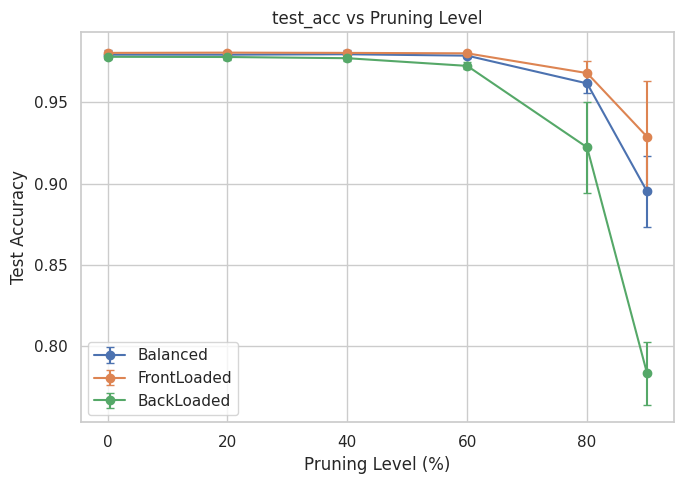

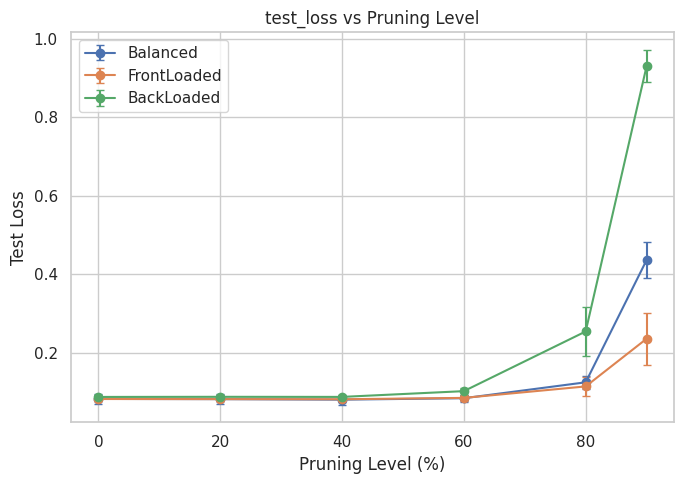

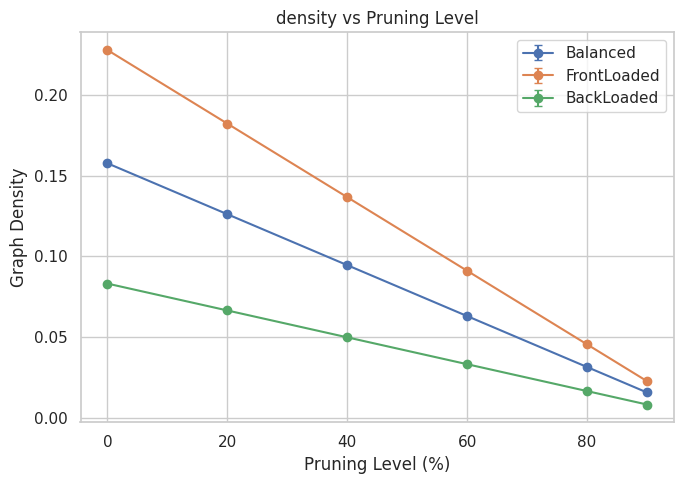

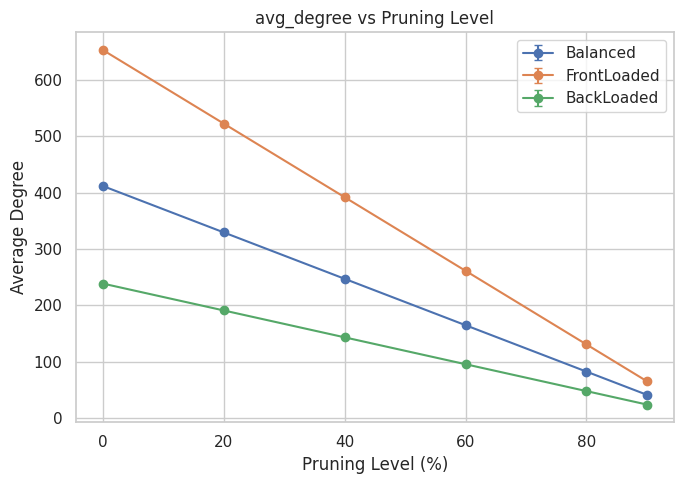

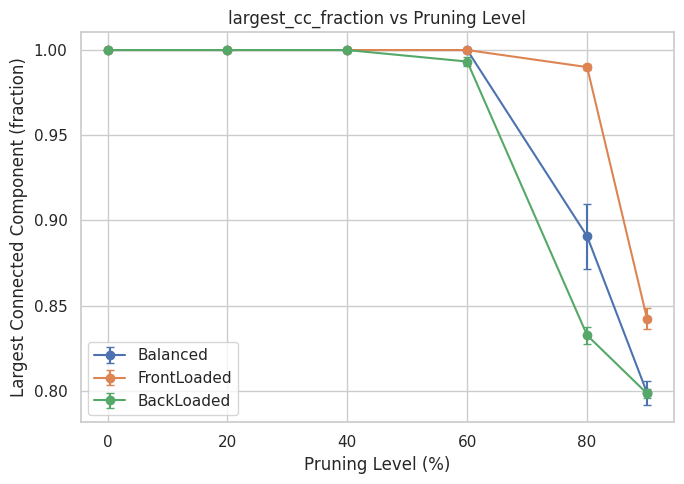

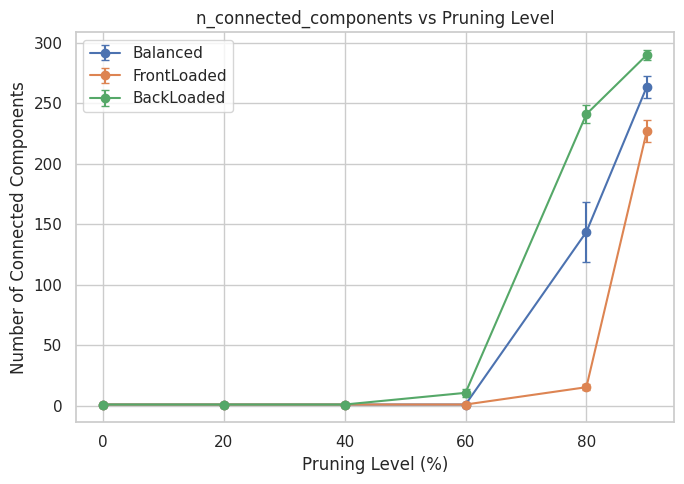

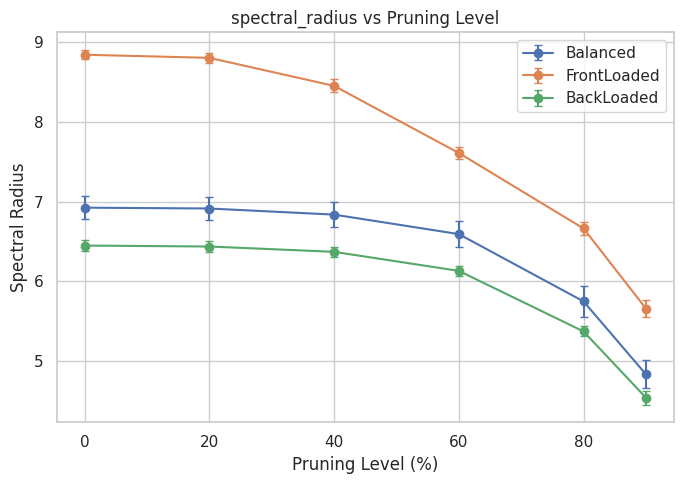

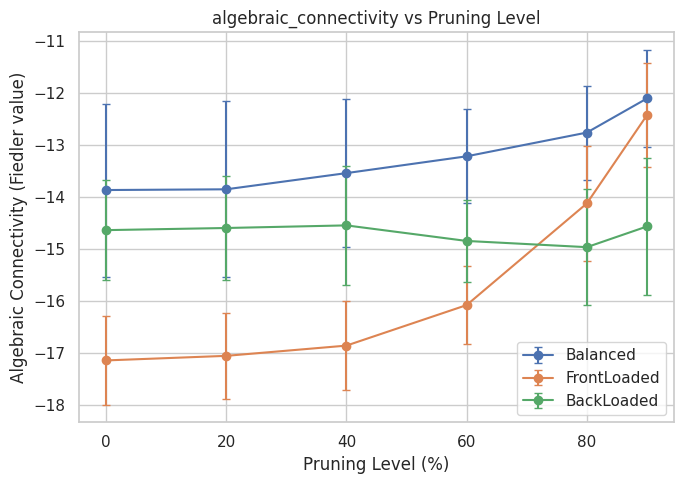

In [ ]:
sns.set_theme(style="whitegrid")

def plot_metric_vs_pruning(results_df,metric,ylabel=None,title=None):

    plt.figure(figsize=(7,5))

    for network in results_df.network.unique():
        sub=results_df[results_df.network==network]
        grouped=sub.groupby("pruning_level")[metric].agg(["mean","std"]).reset_index()
        plt.errorbar(grouped.pruning_level*100,grouped["mean"],yerr=grouped["std"],
                     marker="o",capsize=3,label=network)

    plt.xlabel("Pruning Level (%)")
    plt.ylabel(ylabel or metric)
    plt.title(title or f"{metric} vs Pruning Level")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"results/plot_{metric}.png",dpi=150)
    plt.show()


for metric,label in [
    ("test_acc","Test Accuracy"),
    ("test_loss","Test Loss"),
    ("density","Graph Density"),
    ("avg_degree","Average Degree"),
    ("largest_cc_fraction","Largest Connected Component (fraction)"),
    ("n_connected_components","Number of Connected Components"),
    ("spectral_radius","Spectral Radius"),
    ("algebraic_connectivity","Algebraic Connectivity (Fiedler value)"),
]:
    plot_metric_vs_pruning(results_df,metric,ylabel=label)


### 18b. Degree Distributions, Adjacency Heatmaps, Weight Histograms, Activations

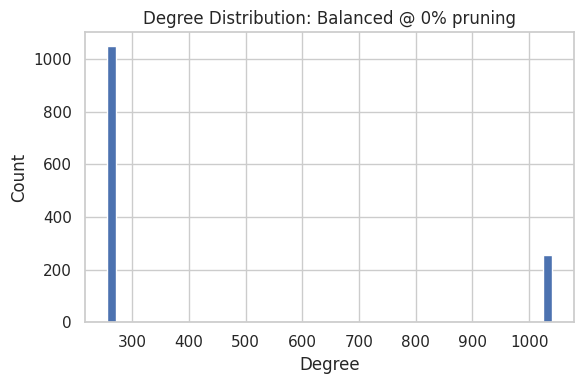

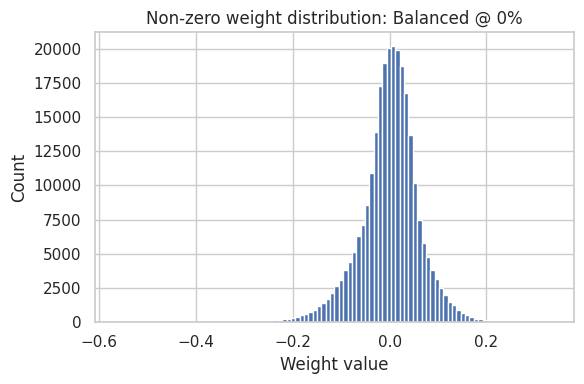

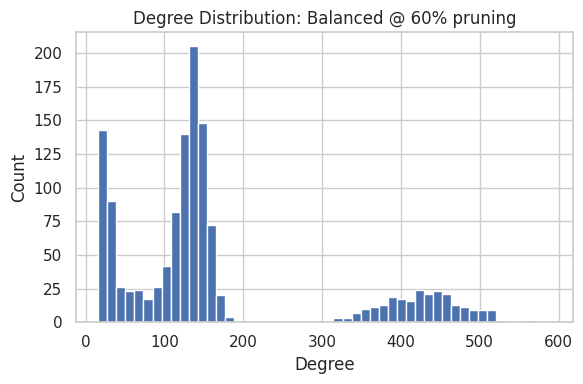

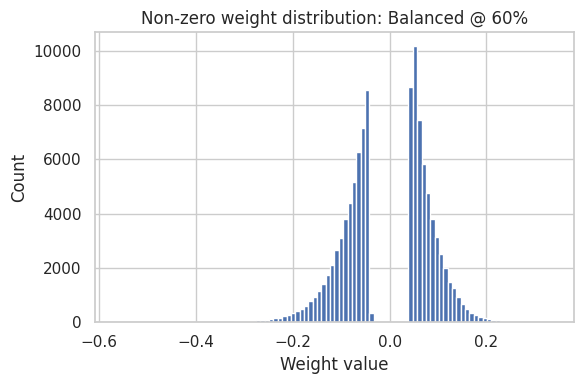

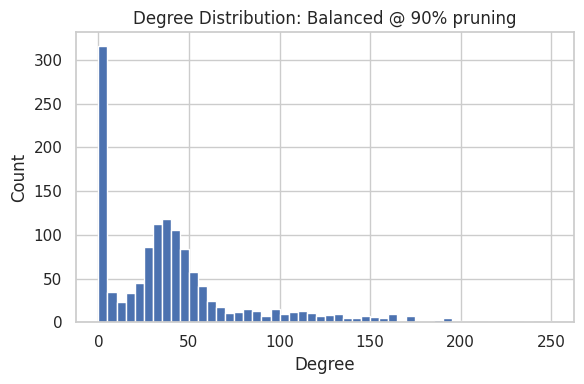

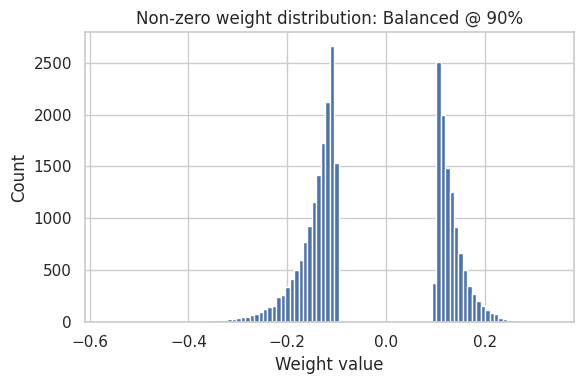

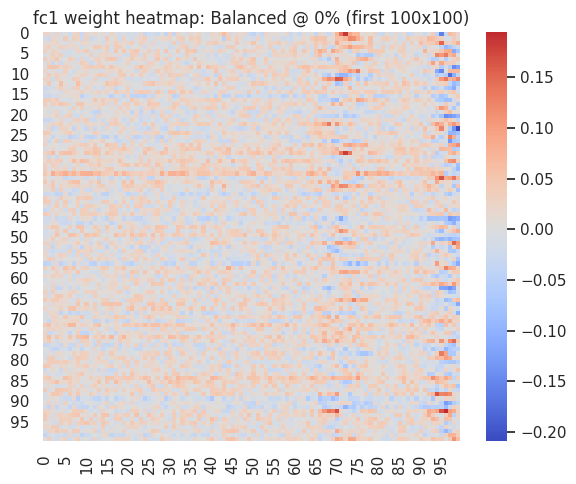

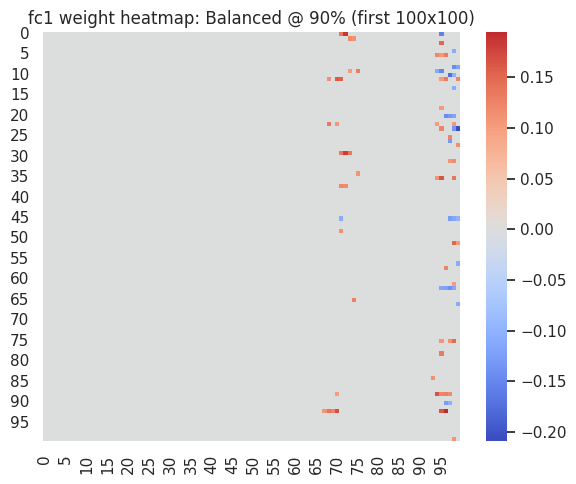

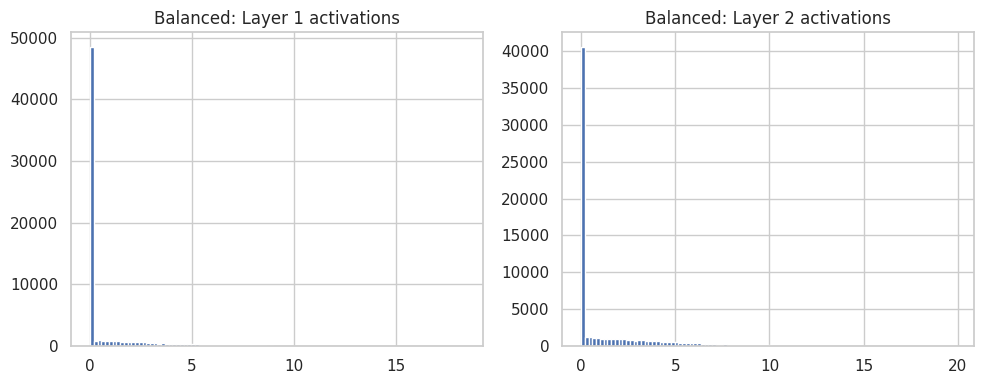

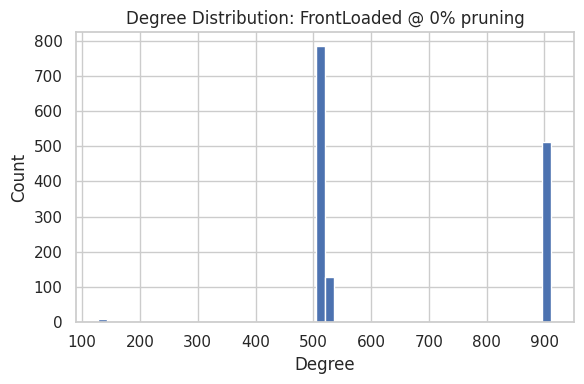

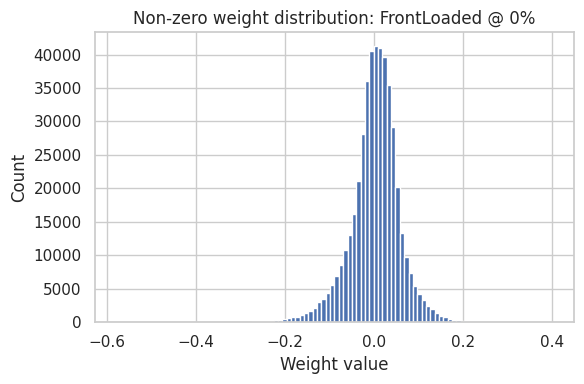

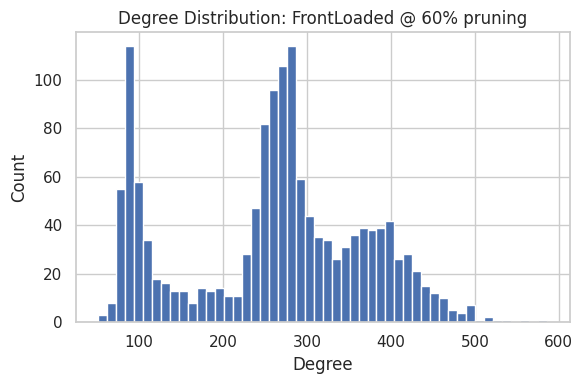

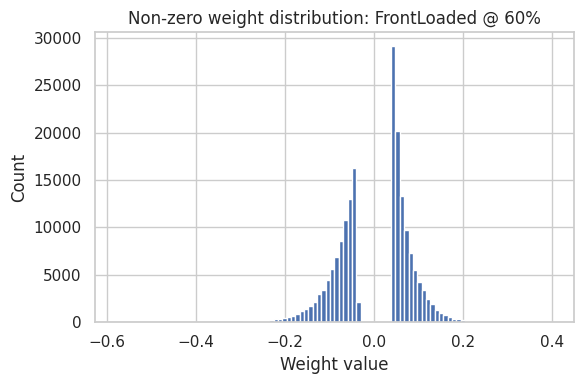

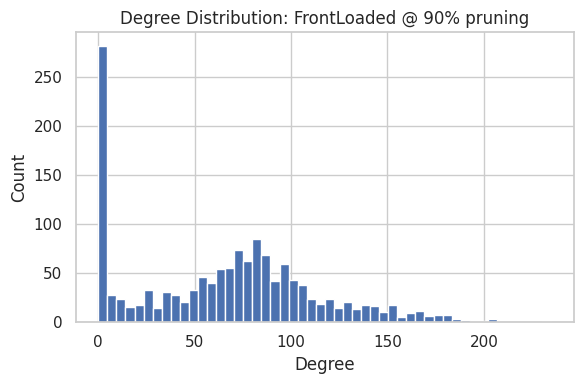

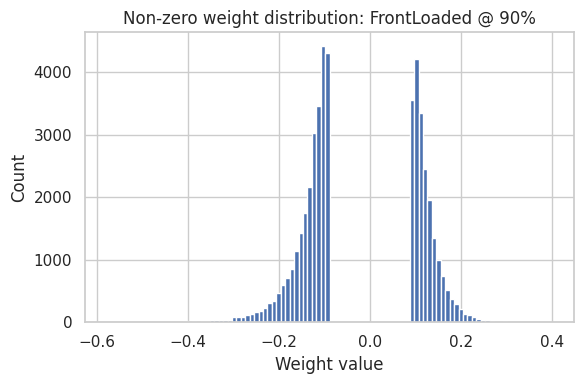

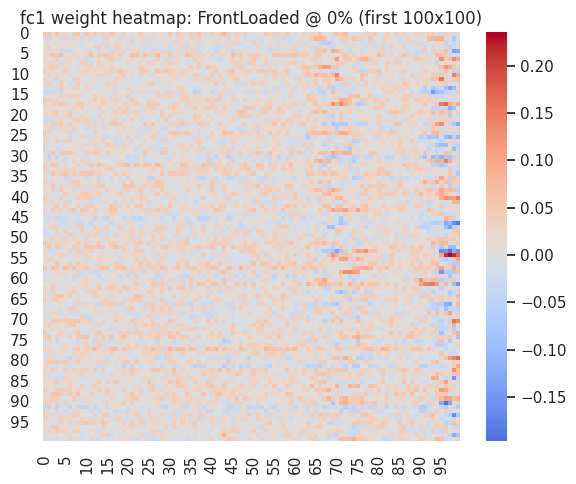

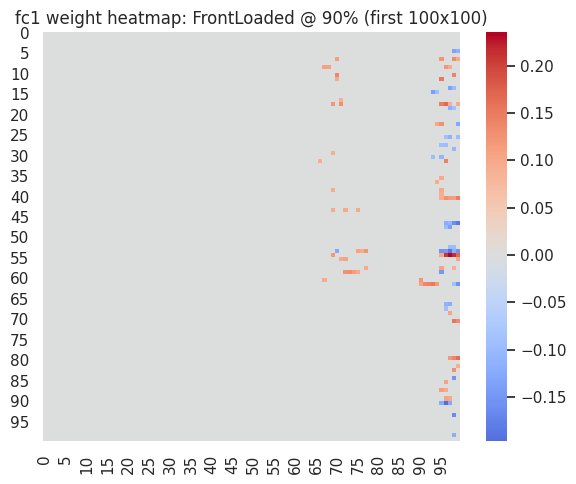

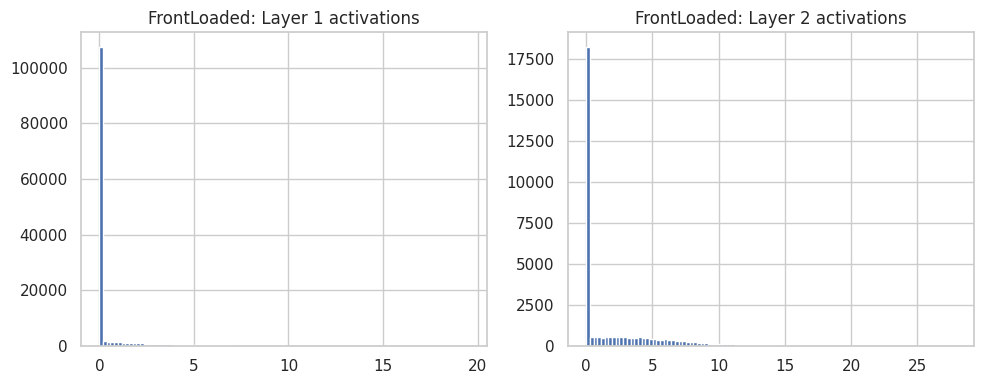

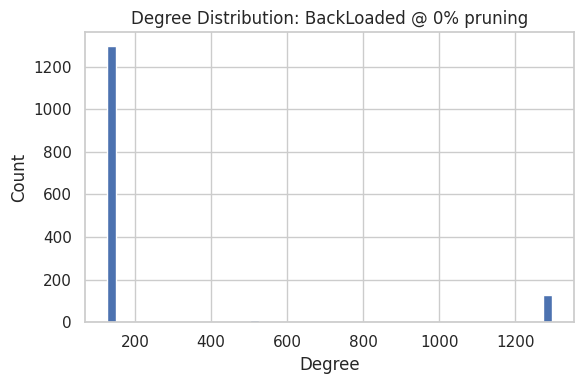

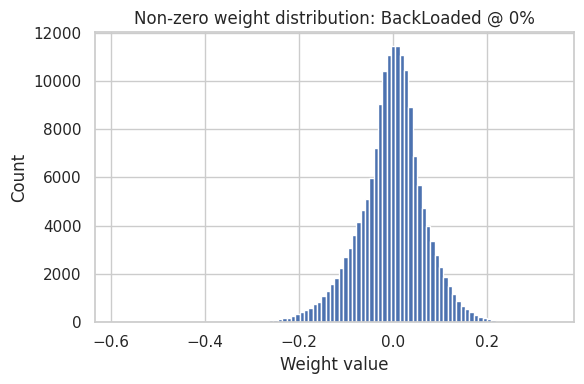

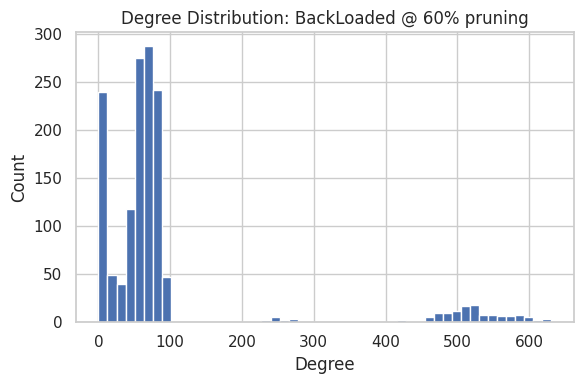

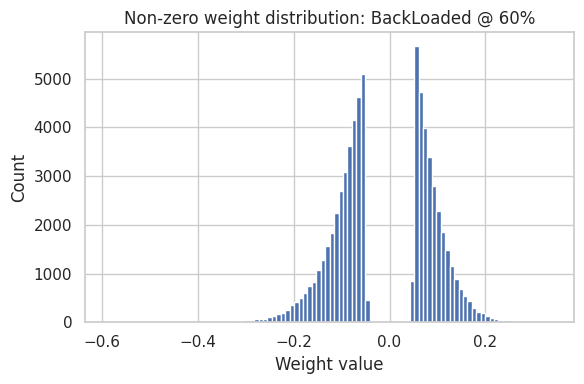

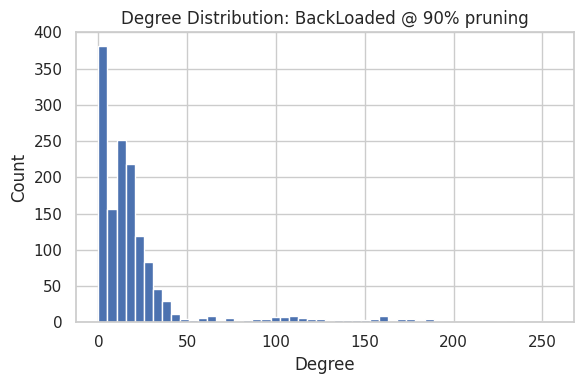

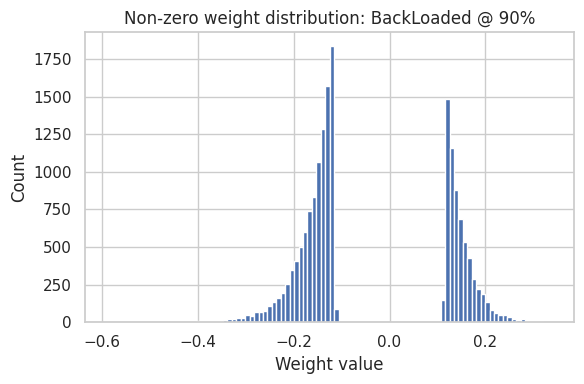

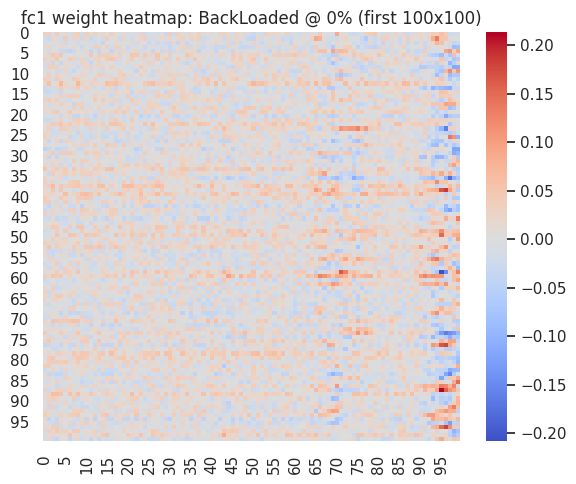

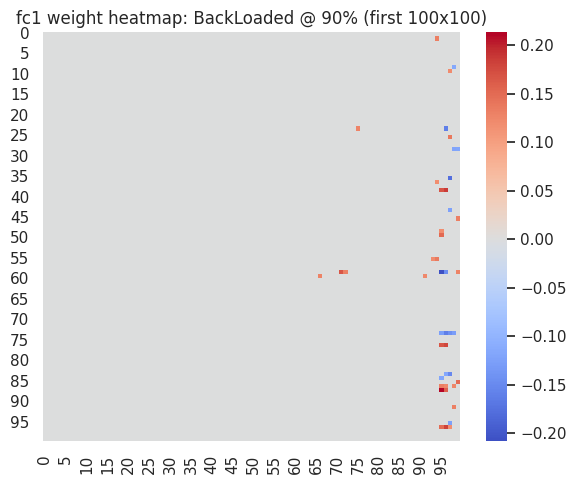

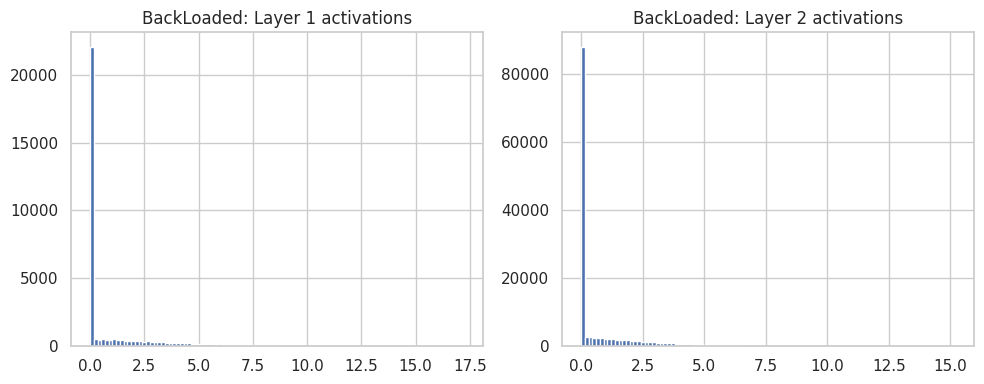

In [ ]:
def plot_degree_distribution(model,pruning_level,network_name):

    pruned_model=apply_global_pruning(model,pruning_level)
    G=model_to_graph(pruned_model)
    degrees=[d for _,d in G.degree()]

    plt.figure(figsize=(6,4))
    plt.hist(degrees,bins=50)
    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title(f"Degree Distribution: {network_name} @ {pruning_level:.0%} pruning")
    plt.tight_layout()
    plt.savefig(f"results/degree_dist_{network_name}_{int(pruning_level*100)}.png",dpi=150)
    plt.show()


def plot_adjacency_heatmap(model,pruning_level,network_name,layer="fc1",max_dim=100):

    pruned_model=apply_global_pruning(model,pruning_level)
    layer_module=getattr(pruned_model,layer)
    W=layer_module.weight.detach().cpu().numpy()
    W_sub=W[:max_dim,:max_dim]

    plt.figure(figsize=(6,5))
    sns.heatmap(W_sub,cmap="coolwarm",center=0,cbar=True)
    plt.title(f"{layer} weight heatmap: {network_name} @ {pruning_level:.0%} (first {max_dim}x{max_dim})")
    plt.tight_layout()
    plt.savefig(f"results/heatmap_{network_name}_{layer}_{int(pruning_level*100)}.png",dpi=150)
    plt.show()


def plot_weight_histogram(model,pruning_level,network_name):

    pruned_model=apply_global_pruning(model,pruning_level)
    all_weights=np.concatenate([
        pruned_model.fc1.weight.detach().cpu().numpy().flatten(),
        pruned_model.fc2.weight.detach().cpu().numpy().flatten(),
        pruned_model.fc3.weight.detach().cpu().numpy().flatten(),
    ])
    nonzero_weights=all_weights[all_weights!=0]

    plt.figure(figsize=(6,4))
    plt.hist(nonzero_weights,bins=100)
    plt.xlabel("Weight value")
    plt.ylabel("Count")
    plt.title(f"Non-zero weight distribution: {network_name} @ {pruning_level:.0%}")
    plt.tight_layout()
    plt.savefig(f"results/weight_hist_{network_name}_{int(pruning_level*100)}.png",dpi=150)
    plt.show()


def plot_activation_distributions(model,network_name):

    model.eval()
    images,_=next(iter(testloader))
    images=images.to(device)

    with torch.no_grad():
        x=images.view(-1,784)
        a1=model.relu(model.fc1(x))
        a2=model.relu(model.fc2(a1))

    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].hist(a1.detach().cpu().numpy().flatten(),bins=100)
    axes[0].set_title(f"{network_name}: Layer 1 activations")
    axes[1].hist(a2.detach().cpu().numpy().flatten(),bins=100)
    axes[1].set_title(f"{network_name}: Layer 2 activations")
    plt.tight_layout()
    plt.savefig(f"results/activations_{network_name}.png",dpi=150)
    plt.show()


for network_name in models:
    model=trained_models[(network_name,0)]
    for level in [0.0,0.6,0.9]:
        plot_degree_distribution(model,level,network_name)
        plot_weight_histogram(model,level,network_name)
    for level in [0.0,0.9]:
        plot_adjacency_heatmap(model,level,network_name,layer="fc1")
    plot_activation_distributions(model,network_name)


### 18c. Eigenvalue Spectra, Layer-wise Sparsity, Confusion Matrices

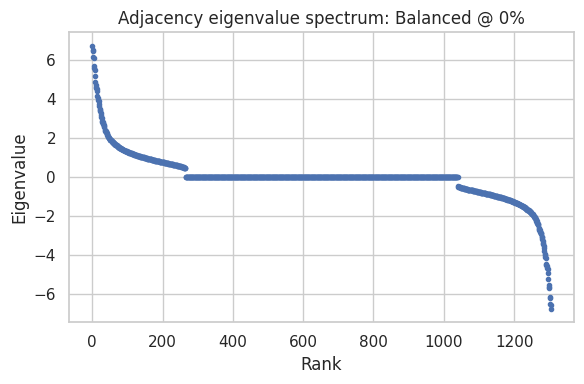

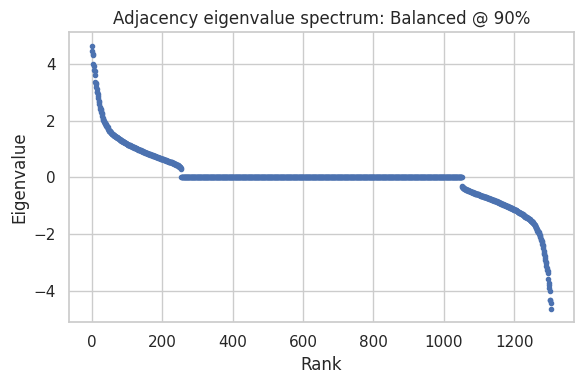

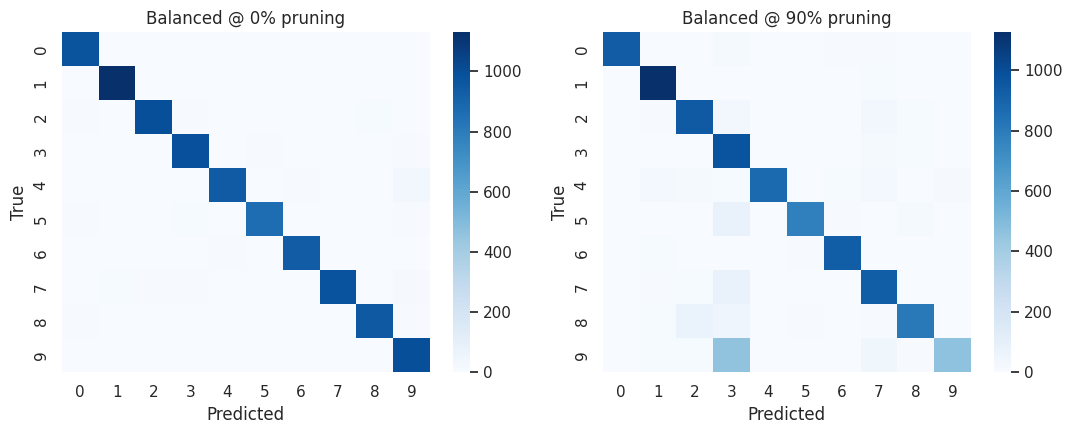

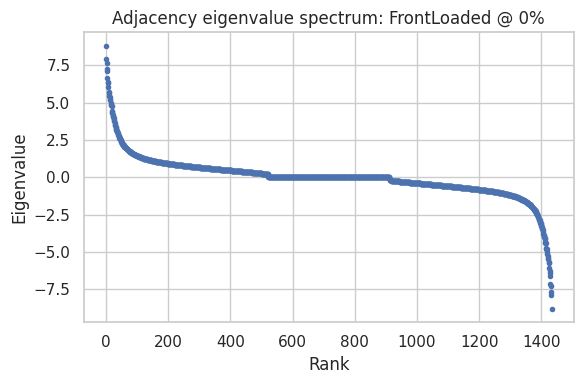

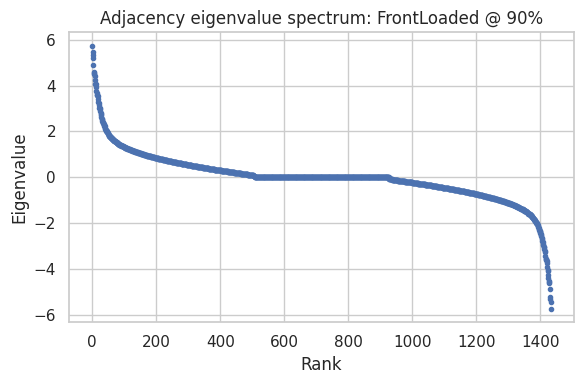

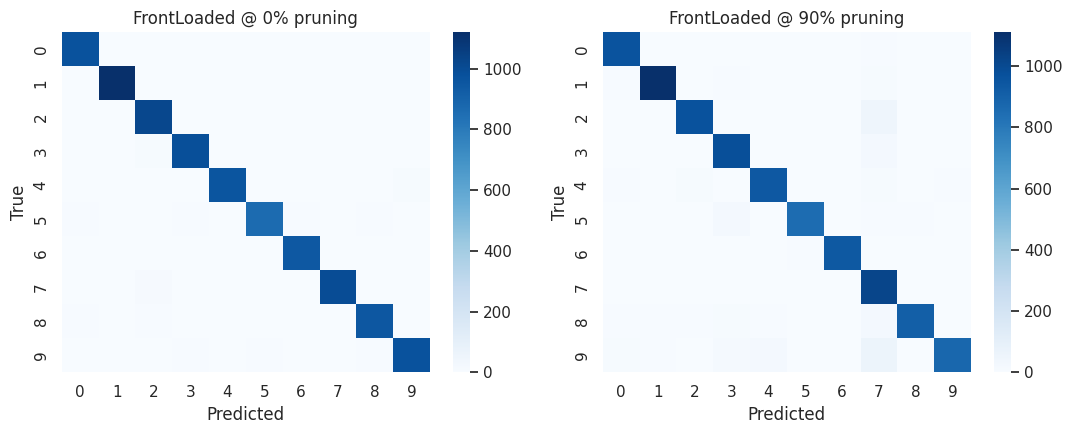

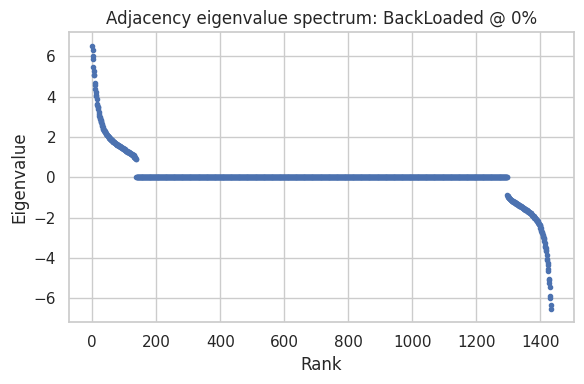

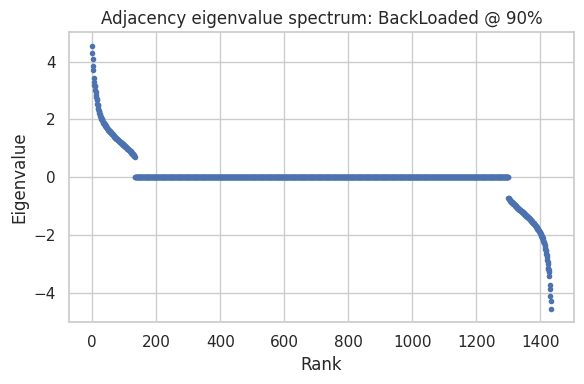

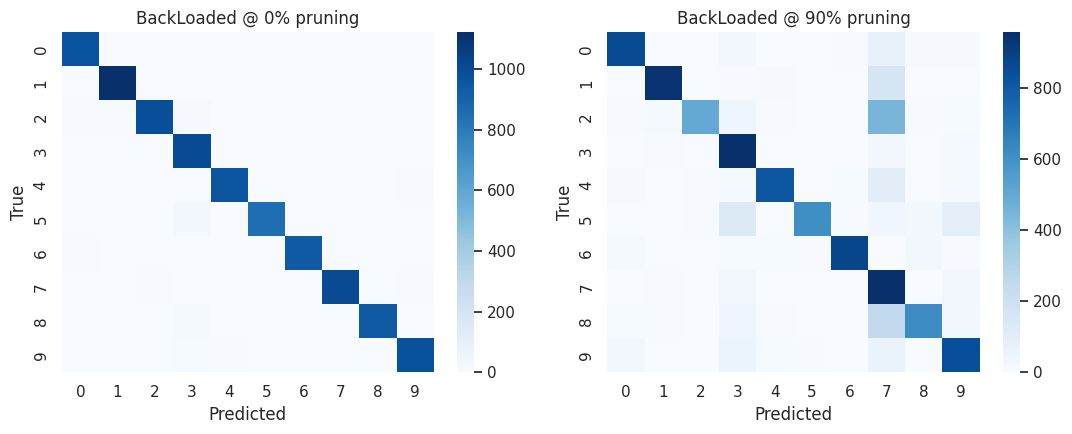

sparsity_fc1  sparsity_fc2  sparsity_fc3  \
network     pruning_level                                             
BackLoaded  0.0                0.000000      0.000000      0.000000   
            0.2                0.250708      0.127070      0.139714   
            0.4                0.495297      0.262115      0.297070   
            0.6                0.712296      0.435699      0.502083   
            0.8                0.874186      0.690241      0.750781   
            0.9                0.943157      0.836538      0.866406   
Balanced    0.0                0.000000      0.000000      0.000000   
            0.2                0.221404      0.138056      0.107682   
            0.4                0.440068      0.284444      0.216927   
            0.6                0.649296      0.458440      0.359115   
            0.8                0.833765      0.704336      0.601823   
            0.9                0.918816      0.847087      0.779427   
FrontLoaded 0.0                0.000000      0.000000      0.000000   
            0.2                0.206778      0.160797      0.081771   
            0.4                0.412485      0.328044      0.169271   
            0.6                0.614709      0.516307      0.272135   
            0.8                0.811646      0.735357      0.457292   
            0.9                0.906586      0.864553      0.649740   

                           sparsity_global  
network     pruning_level                   
BackLoaded  0.0                   0.000000  
            0.2                   0.200002  
            0.4                   0.399999  
            0.6                   0.600001  
            0.8                   0.799998  
            0.9                   0.899999  
Balanced    0.0                   0.000000  
            0.2                   0.200000  
            0.4                   0.400000  
            0.6                   0.600000  
            0.8                   0.800000  
            0.9                   0.900000  
FrontLoaded 0.0                   0.000000  
            0.2                   0.200000  
            0.4                   0.400001  
            0.6                   0.599999  
            0.8                   0.800000  
            0.9                   0.900001

In [ ]:
def plot_eigenvalue_spectrum(model,pruning_level,network_name):

    pruned_model=apply_global_pruning(model,pruning_level)
    G=model_to_graph(pruned_model).to_undirected()
    A=nx.to_numpy_array(G)
    eigvals=np.sort(np.linalg.eigvals(A).real)[::-1]

    plt.figure(figsize=(6,4))
    plt.plot(eigvals,marker=".",linestyle="none")
    plt.xlabel("Rank")
    plt.ylabel("Eigenvalue")
    plt.title(f"Adjacency eigenvalue spectrum: {network_name} @ {pruning_level:.0%}")
    plt.tight_layout()
    plt.savefig(f"results/eigenspectrum_{network_name}_{int(pruning_level*100)}.png",dpi=150)
    plt.show()


def plot_confusion_matrices(network_name):

    model=trained_models[(network_name,0)]
    fig,axes=plt.subplots(1,2,figsize=(11,4.5))

    for ax,level in zip(axes,[0.0,0.9]):
        pruned_model=apply_global_pruning(model,level)
        cm=get_confusion_matrix(pruned_model,testloader)
        sns.heatmap(cm,annot=False,cmap="Blues",ax=ax)
        ax.set_title(f"{network_name} @ {level:.0%} pruning")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.savefig(f"results/confusion_{network_name}.png",dpi=150)
    plt.show()


sparsity_cols=["sparsity_fc1","sparsity_fc2","sparsity_fc3","sparsity_global"]
sparsity_summary=results_df.groupby(["network","pruning_level"])[sparsity_cols].mean()

for network_name in models:
    model=trained_models[(network_name,0)]
    for level in [0.0,0.9]:
        plot_eigenvalue_spectrum(model,level,network_name)
    plot_confusion_matrices(network_name)

sparsity_summary


## 19. Discussion

Fill this in with your actual numbers once the full run has completed. These questions map directly onto the research question in your Literature Review (Section 1.2/1.3) — use `results_df` and `stats_df`.


In [ ]:
# 1. Accuracy vs pruning level
#    Which network's test_acc degrades fastest from 0% to 90% pruning?
#    Does the ranking (Balanced / FrontLoaded / BackLoaded) stay the same
#    at every pruning level, or does the best-performing network at 0%
#    become the worst at 90%?

acc_summary=results_df.groupby(["network","pruning_level"])["test_acc"].mean().unstack("network")
print(acc_summary)

# 2. Structural collapse point
#    Look at largest_cc_fraction and n_connected_components. Does one
#    network's graph fragment (largest_cc drops sharply, extra components
#    appear) at a lower pruning level than the others, and does that
#    line up with where its accuracy starts to fall?

structure_summary=results_df.groupby(["network","pruning_level"])[
    ["largest_cc_fraction","n_connected_components"]
].mean()
print(structure_summary)

# 3. Spectral evidence
#    Higher algebraic_connectivity (Fiedler value) generally means a
#    graph is harder to disconnect. Does the network with the highest
#    algebraic_connectivity at a given pruning level also retain the
#    best accuracy? If not, that's a reportable finding in itself.

spectral_summary=results_df.groupby(["network","pruning_level"])[
    ["spectral_radius","algebraic_connectivity"]
].mean()
print(spectral_summary)

# 4. Isolating connectivity distribution from parameter count
#    If you swapped in the parameter-matched hidden sizes (300/109,
#    180/670) before running Section 16, any differences you see here
#    are attributable to connectivity distribution alone. If you used
#    the original 512/128 and 128/512 shapes, report the parameter
#    counts from earlier alongside these results and treat that as an
#    explicit limitation rather than ignoring it.

significant=stats_df[stats_df.p_value<0.05].sort_values("p_value")
print(f"\n{len(significant)} statistically significant comparisons (p<0.05) out of {len(stats_df)}:")
print(significant)

# 5. Where accuracy and structure disagree
#    Note any pruning level where the accuracy ranking and the
#    structural-robustness ranking (e.g. by algebraic_connectivity)
#    of the three networks don't match. A nuanced finding here is more
#    valuable than forcing a clean "structure explains everything" story.

# 6. Limitations to state explicitly
#    - Parameter-count caveat (Section 7), if using the original shapes.
#    - Betweenness centrality (Section 13) is sampled, not exact.
#    - n_seeds trades statistical power against training time -- state
#      how many seeds you used and why.


network        BackLoaded  Balanced  FrontLoaded
pruning_level                                   
0.0              0.977967  0.979267     0.980367
0.2              0.977833  0.979267     0.980533
0.4              0.977100  0.979533     0.980367
0.6              0.972367  0.978667     0.980100
0.8              0.922233  0.961600     0.967933
0.9              0.783267  0.895133     0.928767
                           largest_cc_fraction  n_connected_components
network     pruning_level                                             
BackLoaded  0.0                       1.000000                1.000000
            0.2                       1.000000                1.000000
            0.4                       1.000000                1.000000
            0.6                       0.993259               10.666667
            0.8                       0.832636              241.000000
            0.9                       0.798466              290.000000
Balanced    0.0                       1.

In [ ]:
# 21. Front-Loaded Neuron Count Sweep
#
# FrontLoaded (512/128) outperformed BackLoaded and roughly matched
# Balanced under heavy pruning. This sweep keeps depth fixed at 2
# hidden layers (same as every other network here) and keeps the
# front-loaded character (h1>h2), but varies the actual neuron counts
# to search for a configuration that prunes even better than 512/128.

class FrontLoadedVariant(nn.Module):

    def __init__(self,h1,h2):

        super().__init__()

        self.fc1=nn.Linear(784,h1)

        self.fc2=nn.Linear(h1,h2)

        self.fc3=nn.Linear(h2,10)

        self.relu=nn.ReLU()

    def forward(self,x):

        x=x.view(-1,784)

        x=self.relu(self.fc1(x))

        x=self.relu(self.fc2(x))

        x=self.fc3(x)

        return x


# candidate (h1,h2) pairs, all front-loaded (h1>h2), spanning smaller
# to larger than the original 512/128 -- 512/128 is included as a
# reference point so the sweep can be compared directly to Section 16
frontloaded_candidates=[
    (256,64),
    (384,96),
    (512,128),
    (640,160),
    (768,192),
]

def run_frontloaded_sweep(candidates,pruning_levels,n_seeds=3,epochs=10):

    sweep_results=[]
    sweep_models={}

    for h1,h2 in candidates:

        tag=f"FL_{h1}_{h2}"

        for s in range(n_seeds):

            random.seed(seed+s)
            np.random.seed(seed+s)
            torch.manual_seed(seed+s)

            print(f"\n=== Training {tag} (seed {s}) ===")

            model=FrontLoadedVariant(h1,h2).to(device)
            total_params=count_parameters(model)

            train_model(model,trainloader,testloader,epochs=epochs,verbose=False)
            sweep_models[(tag,s)]=model

            for level in pruning_levels:

                pruned_model=apply_global_pruning(model,level)
                test_loss,test_acc=evaluate_model(pruned_model,testloader)

                sweep_results.append({
                    "config":tag,
                    "h1":h1,
                    "h2":h2,
                    "seed":s,
                    "pruning_level":level,
                    "total_params":total_params,
                    "test_acc":test_acc,
                    "test_loss":test_loss,
                })

            last_acc=sweep_results[-1]["test_acc"]
            print(f"  {tag} seed {s}: params={total_params} final(90%)_acc={last_acc:.4f}")

    return pd.DataFrame(sweep_results),sweep_models


# 5 configs x 3 seeds x 10 epochs -- do a smoke test first (n_seeds=1,
# epochs=2) before committing to the full sweep, same as Section 16.
sweep_df,sweep_models=run_frontloaded_sweep(frontloaded_candidates,pruning_levels,n_seeds=3,epochs=10)
sweep_df.to_csv("results/frontloaded_sweep.csv",index=False)
sweep_df.head(20)


=== Training FL_256_64 (seed 0) ===
  FL_256_64 seed 0: params=218058 final(90%)_acc=0.8996

=== Training FL_256_64 (seed 1) ===
  FL_256_64 seed 1: params=218058 final(90%)_acc=0.8939

=== Training FL_256_64 (seed 2) ===
  FL_256_64 seed 2: params=218058 final(90%)_acc=0.9476

=== Training FL_384_96 (seed 0) ===
  FL_384_96 seed 0: params=339370 final(90%)_acc=0.9531

=== Training FL_384_96 (seed 1) ===
  FL_384_96 seed 1: params=339370 final(90%)_acc=0.9408

=== Training FL_384_96 (seed 2) ===
  FL_384_96 seed 2: params=339370 final(90%)_acc=0.9466

=== Training FL_512_128 (seed 0) ===
  FL_512_128 seed 0: params=468874 final(90%)_acc=0.9538

=== Training FL_512_128 (seed 1) ===
  FL_512_128 seed 1: params=468874 final(90%)_acc=0.9431

=== Training FL_512_128 (seed 2) ===
  FL_512_128 seed 2: params=468874 final(90%)_acc=0.8894

=== Training FL_640_160 (seed 0) ===
  FL_640_160 seed 0: params=606570 final(90%)_acc=0.9547

=== Training FL_640_160 (seed 1) ===
  FL_640_160 seed 1: par

,config,h1,h2,seed,pruning_level,total_params,test_acc,test_loss
0,FL_256_64,256,64,0,0.0,218058,0.9812,0.076736
1,FL_256_64,256,64,0,0.2,218058,0.9814,0.076763
2,FL_256_64,256,64,0,0.4,218058,0.9811,0.077387
3,FL_256_64,256,64,0,0.6,218058,0.9775,0.084118
4,FL_256_64,256,64,0,0.8,218058,0.9474,0.180176
5,FL_256_64,256,64,0,0.9,218058,0.8996,0.319871
6,FL_256_64,256,64,1,0.0,218058,0.9796,0.077477
7,FL_256_64,256,64,1,0.2,218058,0.9795,0.077285
8,FL_256_64,256,64,1,0.4,218058,0.9800,0.076234
9,FL_256_64,256,64,1,0.6,218058,0.9798,0.079031


pruning_level            0.0       0.2       0.4       0.6       0.8       0.9
config     h1  h2                                                             
FL_256_64  256 64   0.980467  0.980533  0.980667  0.979367  0.956500  0.913700
FL_384_96  384 96   0.979767  0.979833  0.979867  0.979667  0.970333  0.946833
FL_512_128 512 128  0.980367  0.980533  0.980367  0.980100  0.967933  0.928767
FL_640_160 640 160  0.979067  0.979067  0.979967  0.980067  0.974800  0.954667
FL_768_192 768 192  0.979200  0.979200  0.979100  0.979367  0.972433  0.942933

Ranking by accuracy at 90% pruning:
config
FL_640_160    0.954667
FL_384_96     0.946833
FL_768_192    0.942933
FL_512_128    0.928767
FL_256_64     0.913700
Name: test_acc, dtype: float64

Ranking by mean accuracy across all pruning levels:
config
FL_640_160    0.974606
FL_384_96     0.972717
FL_768_192    0.972039
FL_512_128    0.969678
FL_256_64     0.965206
Name: test_acc, dtype: float64

Best at 90% pruning: FL_640_160
Best overall: FL_6

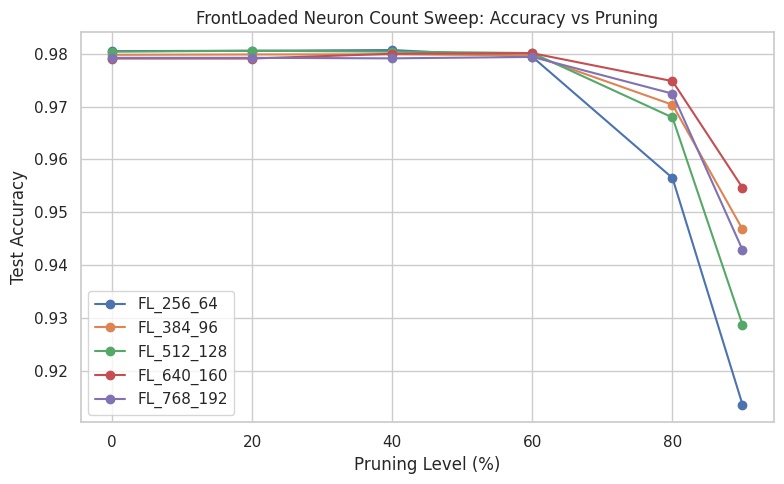

In [ ]:
# 21b. Sweep Analysis: Finding the Optimal FrontLoaded Configuration

sweep_summary=sweep_df.groupby(["config","h1","h2","pruning_level"])["test_acc"].mean().unstack("pruning_level")
print(sweep_summary)

acc_90=sweep_df[sweep_df.pruning_level==0.9].groupby("config")["test_acc"].mean().sort_values(ascending=False)
print("\nRanking by accuracy at 90% pruning:")
print(acc_90)

# a second view: average accuracy across ALL pruning levels, in case
# the best configuration at 90% isn't the best configuration overall
acc_overall=sweep_df.groupby("config")["test_acc"].mean().sort_values(ascending=False)
print("\nRanking by mean accuracy across all pruning levels:")
print(acc_overall)

best_config_90=acc_90.idxmax()
best_config_overall=acc_overall.idxmax()
print(f"\nBest at 90% pruning: {best_config_90}")
print(f"Best overall: {best_config_overall}")

plt.figure(figsize=(8,5))
for config in sweep_df.config.unique():
    sub=sweep_df[sweep_df.config==config]
    grouped=sub.groupby("pruning_level")["test_acc"].mean().reset_index()
    plt.plot(grouped.pruning_level*100,grouped["test_acc"],marker="o",label=config)
plt.xlabel("Pruning Level (%)")
plt.ylabel("Test Accuracy")
plt.title("FrontLoaded Neuron Count Sweep: Accuracy vs Pruning")
plt.legend()
plt.tight_layout()
plt.savefig("results/frontloaded_sweep_accuracy.png",dpi=150)
plt.show()

In [ ]:
# 22. Minimum-Degree Node Pruning
#
# After magnitude-based edge pruning, some neurons end up with very few
# remaining connections ("nearly dead" neurons). This removes any
# hidden neuron whose degree (incoming + outgoing non-zero weights)
# falls below a threshold, by zeroing ALL of its weights -- on top of
# the existing weight-level pruning -- and measures the extra effect
# on accuracy and connectivity.

def remove_low_degree_nodes(model,min_degree):
    """
    Only h1 and h2 neurons are removed -- input pixels and output
    classes are never touched, since removing them isn't meaningful.
    """
    model=copy.deepcopy(model)

    W1=model.fc1.weight.data  # shape (h1,784)
    W2=model.fc2.weight.data  # shape (h2,h1)
    W3=model.fc3.weight.data  # shape (10,h2)

    h1_in_degree=(W1!=0).sum(dim=1)
    h1_out_degree=(W2!=0).sum(dim=0)
    h1_degree=h1_in_degree+h1_out_degree

    h2_in_degree=(W2!=0).sum(dim=1)
    h2_out_degree=(W3!=0).sum(dim=0)
    h2_degree=h2_in_degree+h2_out_degree

    h1_to_remove=(h1_degree<min_degree).nonzero(as_tuple=True)[0]
    h2_to_remove=(h2_degree<min_degree).nonzero(as_tuple=True)[0]

    if len(h1_to_remove)>0:
        W1[h1_to_remove,:]=0.0
        W2[:,h1_to_remove]=0.0

    if len(h2_to_remove)>0:
        W2[h2_to_remove,:]=0.0
        W3[:,h2_to_remove]=0.0

    return model,len(h1_to_remove),len(h2_to_remove)


min_degree_thresholds=[0,1,2,5,10]  # 0 = no extra node removal (baseline, matches Section 16)

node_pruning_results=[]

for network_name in models:

    model=trained_models[(network_name,0)]

    for level in pruning_levels:

        pruned_model=apply_global_pruning(model,level)

        for min_degree in min_degree_thresholds:

            trimmed_model,n_h1_removed,n_h2_removed=remove_low_degree_nodes(pruned_model,min_degree)
            test_loss,test_acc=evaluate_model(trimmed_model,testloader)

            G=model_to_graph(trimmed_model,weight_threshold=0.0)
            graph_metrics=compute_graph_metrics(G)

            node_pruning_results.append({
                "network":network_name,
                "pruning_level":level,
                "min_degree":min_degree,
                "n_h1_removed":n_h1_removed,
                "n_h2_removed":n_h2_removed,
                "test_acc":test_acc,
                "test_loss":test_loss,
                **graph_metrics,
            })

node_pruning_df=pd.DataFrame(node_pruning_results)
node_pruning_df.to_csv("results/min_degree_node_pruning.csv",index=False)
node_pruning_df.head(20)

,network,pruning_level,min_degree,n_h1_removed,n_h2_removed,test_acc,test_loss,n_nodes,n_edges,density,avg_degree,n_connected_components,largest_cc_size,largest_cc_fraction
0,Balanced,0.0,0,0,0,0.9760,0.098328,1306,268800,0.157716,411.638591,1,1306,1.0
1,Balanced,0.0,1,0,0,0.9760,0.098328,1306,268800,0.157716,411.638591,1,1306,1.0
2,Balanced,0.0,2,0,0,0.9760,0.098328,1306,268800,0.157716,411.638591,1,1306,1.0
3,Balanced,0.0,5,0,0,0.9760,0.098328,1306,268800,0.157716,411.638591,1,1306,1.0
4,Balanced,0.0,10,0,0,0.9760,0.098328,1306,268800,0.157716,411.638591,1,1306,1.0
5,Balanced,0.2,0,0,0,0.9765,0.097512,1306,215040,0.126173,329.310873,1,1306,1.0
6,Balanced,0.2,1,0,0,0.9765,0.097512,1306,215040,0.126173,329.310873,1,1306,1.0
7,Balanced,0.2,2,0,0,0.9765,0.097512,1306,215040,0.126173,329.310873,1,1306,1.0
8,Balanced,0.2,5,0,0,0.9765,0.097512,1306,215040,0.126173,329.310873,1,1306,1.0
9,Balanced,0.2,10,0,0,0.9765,0.097512,1306,215040,0.126173,329.310873,1,1306,1.0


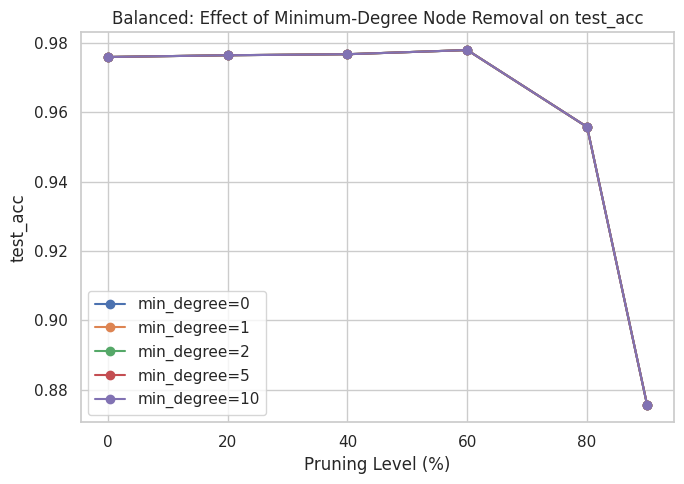

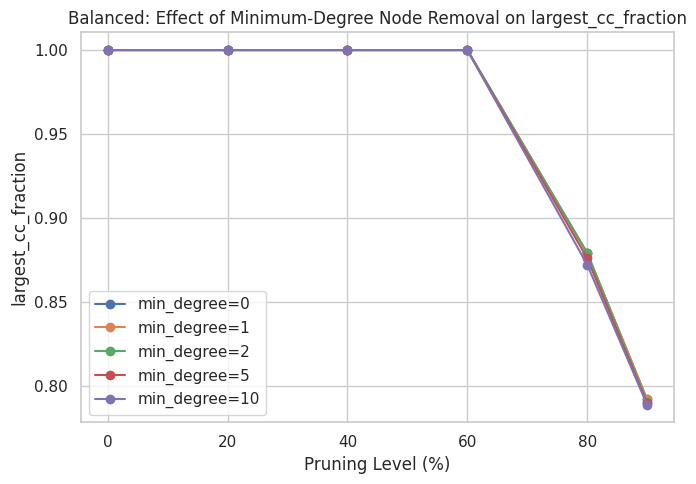

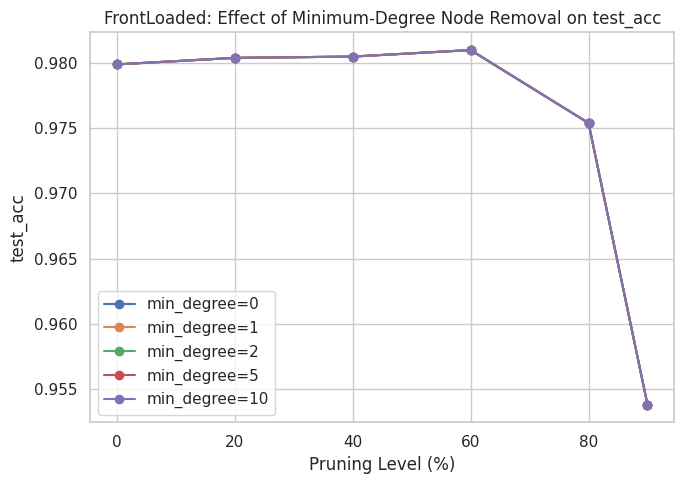

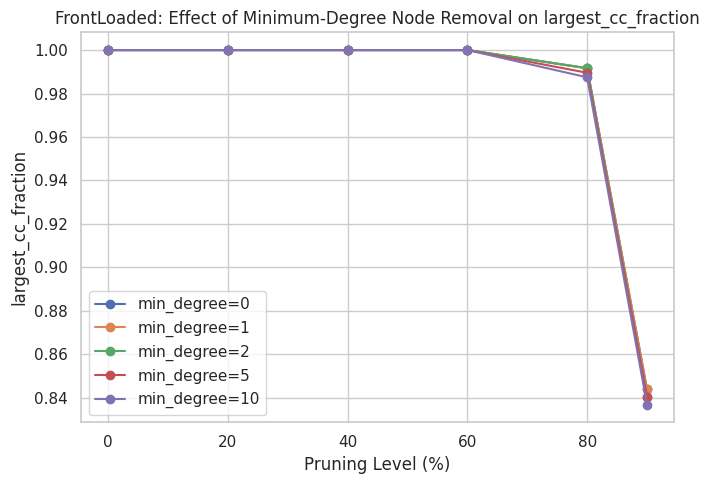

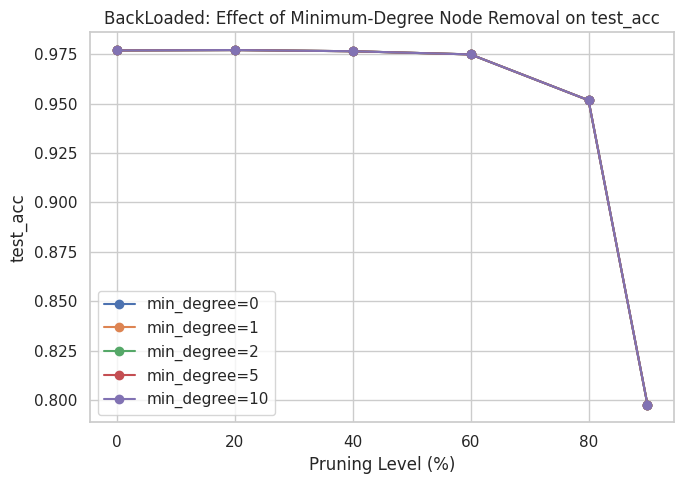

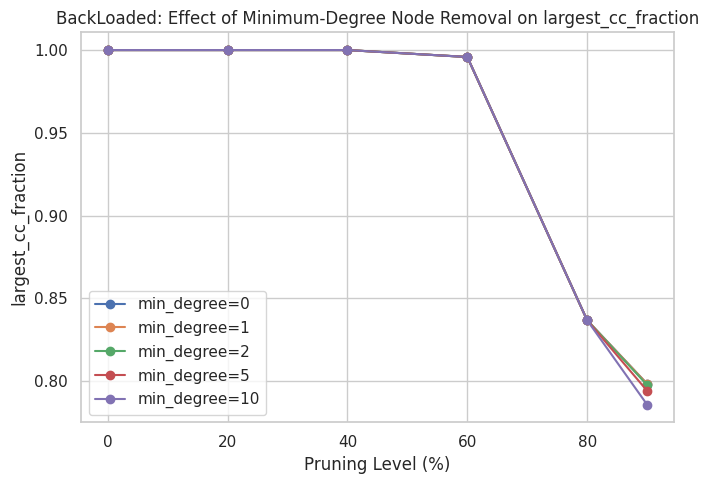

n_h1_removed  n_h2_removed
network     pruning_level min_degree                            
BackLoaded  0.0           0                    0.0           0.0
                          1                    0.0           0.0
                          2                    0.0           0.0
                          5                    0.0           0.0
                          10                   0.0           0.0
...                                            ...           ...
FrontLoaded 0.9           0                    0.0           0.0
                          1                   15.0           4.0
                          2                   15.0           9.0
                          5                   15.0           9.0
                          10                  20.0           9.0

[90 rows x 2 columns]

In [ ]:
# 22b. Effect of Minimum-Degree Node Removal

def plot_min_degree_effect(network_name,metric="test_acc"):

    sub=node_pruning_df[node_pruning_df.network==network_name]

    plt.figure(figsize=(7,5))
    for min_degree in sorted(sub.min_degree.unique()):
        s=sub[sub.min_degree==min_degree]
        plt.plot(s.pruning_level*100,s[metric],marker="o",label=f"min_degree={min_degree}")

    plt.xlabel("Pruning Level (%)")
    plt.ylabel(metric)
    plt.title(f"{network_name}: Effect of Minimum-Degree Node Removal on {metric}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"results/min_degree_{network_name}_{metric}.png",dpi=150)
    plt.show()


for network_name in models:
    plot_min_degree_effect(network_name,metric="test_acc")
    plot_min_degree_effect(network_name,metric="largest_cc_fraction")

# how many neurons were actually removed at each threshold, for context
removal_summary=node_pruning_df.groupby(["network","pruning_level","min_degree"])[
    ["n_h1_removed","n_h2_removed"]
].mean()
removal_summary

In [ ]:
# 23a. Node Removal Robustness Test
#
# Finds the single largest-magnitude weight in the (unpruned) network,
# identifies the neuron it feeds INTO, and removes that neuron entirely
# (zeroing every weight touching it). Compared against removing a
# random other neuron in the same layer, this checks whether the
# network's overall structure depends heavily on the one neuron behind
# its strongest connection, or stays essentially the same either way.

def find_top_edge(model):
    """Returns (layer_name,in_idx,out_idx,weight_value) for the single
    largest-magnitude weight anywhere in the network."""

    best=None

    for layer_name,layer in [("fc1",model.fc1),("fc2",model.fc2),("fc3",model.fc3)]:
        W=layer.weight.data
        flat_idx=torch.argmax(torch.abs(W))
        out_idx,in_idx=divmod(flat_idx.item(),W.shape[1])
        w_val=W[out_idx,in_idx].item()

        if best is None or abs(w_val)>abs(best[3]):
            best=(layer_name,in_idx,out_idx,w_val)

    return best


def remove_single_node(model,layer_name,node_idx,node_side):
    """
    Zeroes every weight touching one specific hidden neuron.
    Only h1 (fc1's output side) and h2 (fc2's output side) neurons can
    be removed this way -- input pixels and output classes cannot.
    """
    model=copy.deepcopy(model)

    if layer_name=="fc1" and node_side=="out":
        model.fc1.weight.data[node_idx,:]=0.0
        model.fc2.weight.data[:,node_idx]=0.0

    elif layer_name=="fc2" and node_side=="out":
        model.fc2.weight.data[node_idx,:]=0.0
        model.fc3.weight.data[:,node_idx]=0.0

    else:
        raise ValueError("Only h1 (fc1 output) and h2 (fc2 output) neurons can be removed this way.")

    return model


robustness_results=[]

for network_name in models:

    model=trained_models[(network_name,0)]
    top_layer,top_in,top_out,top_w=find_top_edge(model)

    print(f"\n{network_name}: largest-magnitude weight is {top_w:.4f} "
          f"in {top_layer}, connecting input-neuron {top_in} -> output-neuron {top_out}")

    if top_layer not in ("fc1","fc2"):
        print("  top weight is in fc3 (output layer) -- skipping node ablation for this network")
        continue

    layer_module=getattr(model,top_layer)
    n_neurons=layer_module.out_features

    random.seed(seed)
    other_candidates=[i for i in range(n_neurons) if i!=top_out]
    random_neuron=random.choice(other_candidates)

    baseline_loss,baseline_acc=evaluate_model(model,testloader)
    baseline_G=model_to_graph(model)
    baseline_metrics=compute_graph_metrics(baseline_G)

    top_ablated=remove_single_node(model,top_layer,top_out,"out")
    top_loss,top_acc=evaluate_model(top_ablated,testloader)
    top_G=model_to_graph(top_ablated)
    top_metrics=compute_graph_metrics(top_G)

    random_ablated=remove_single_node(model,top_layer,random_neuron,"out")
    rand_loss,rand_acc=evaluate_model(random_ablated,testloader)
    rand_G=model_to_graph(random_ablated)
    rand_metrics=compute_graph_metrics(rand_G)

    robustness_results.append({
        "network":network_name,
        "top_layer":top_layer,
        "top_neuron_removed":top_out,
        "random_neuron_removed":random_neuron,
        "baseline_acc":baseline_acc,
        "baseline_largest_cc_fraction":baseline_metrics["largest_cc_fraction"],
        "top_removed_acc":top_acc,
        "top_removed_largest_cc_fraction":top_metrics["largest_cc_fraction"],
        "top_removed_acc_drop":baseline_acc-top_acc,
        "random_removed_acc":rand_acc,
        "random_removed_largest_cc_fraction":rand_metrics["largest_cc_fraction"],
        "random_removed_acc_drop":baseline_acc-rand_acc,
    })

robustness_df=pd.DataFrame(robustness_results)
robustness_df.to_csv("results/single_node_removal_robustness.csv",index=False)
robustness_df


Balanced: largest-magnitude weight is -0.5641 in fc1, connecting input-neuron 271 -> output-neuron 0

FrontLoaded: largest-magnitude weight is -0.5772 in fc1, connecting input-neuron 571 -> output-neuron 172

BackLoaded: largest-magnitude weight is -0.5884 in fc1, connecting input-neuron 181 -> output-neuron 116


,network,top_layer,top_neuron_removed,random_neuron_removed,baseline_acc,baseline_largest_cc_fraction,top_removed_acc,top_removed_largest_cc_fraction,top_removed_acc_drop,random_removed_acc,random_removed_largest_cc_fraction,random_removed_acc_drop
0,Balanced,fc1,0,164,0.9760,1.0,0.9754,0.999234,0.0006,0.9758,0.999234,0.0002
1,FrontLoaded,fc1,172,328,0.9799,1.0,0.9803,0.999303,-0.0004,0.9800,0.999303,-0.0001
2,BackLoaded,fc1,116,81,0.9769,1.0,0.9727,0.999303,0.0042,0.9768,0.999303,0.0001


In [ ]:
# 23b. Weight Migration Tracking
#
# Tracks WHERE the single highest-magnitude weight in the network is
# located (which layer, which input/output neuron pair) at each pruning
# level, to see whether the "strongest connection" stays in the same
# position as pruning proceeds, or a different connection takes over.
#
# Note: global magnitude pruning removes the SMALLEST weights first, so
# the single largest weight is mathematically guaranteed to survive at
# every pruning level up to 100% -- what CAN change is which layer/
# connection currently holds that title, if a bigger one elsewhere gets
# revealed as smaller weights around it are zeroed out.

def top_k_weights(model,k=5):
    """Top-k connections by |weight|, as (layer_name,in_idx,out_idx,weight_value)."""

    entries=[]
    for layer_name,layer in [("fc1",model.fc1),("fc2",model.fc2),("fc3",model.fc3)]:
        W=layer.weight.data.cpu().numpy()
        out_features,in_features=W.shape
        flat=np.abs(W).flatten()
        top_idx=np.argsort(flat)[::-1][:k]
        for idx in top_idx:
            out_idx,in_idx=divmod(idx,in_features)
            entries.append((layer_name,int(in_idx),int(out_idx),float(W[out_idx,in_idx])))

    entries.sort(key=lambda e:-abs(e[3]))
    return entries[:k]


migration_records=[]

for network_name in models:

    model=trained_models[(network_name,0)]

    for level in pruning_levels:

        pruned_model=apply_global_pruning(model,level)
        top1=top_k_weights(pruned_model,k=1)[0]

        migration_records.append({
            "network":network_name,
            "pruning_level":level,
            "top_layer":top1[0],
            "top_in_idx":top1[1],
            "top_out_idx":top1[2],
            "top_weight":top1[3],
        })

migration_df=pd.DataFrame(migration_records)
migration_df.to_csv("results/weight_migration_tracking.csv",index=False)

for network_name in models:
    sub=migration_df[migration_df.network==network_name]
    same_connection=sub[["top_layer","top_in_idx","top_out_idx"]].nunique().eq(1).all()
    print(f"\n{network_name}: top weight stays on the SAME connection across all pruning "
          f"levels = {same_connection}")
    print(sub[["pruning_level","top_layer","top_in_idx","top_out_idx","top_weight"]].to_string(index=False))


Balanced: top weight stays on the SAME connection across all pruning levels = True
 pruning_level top_layer  top_in_idx  top_out_idx  top_weight
           0.0       fc1         271            0   -0.564111
           0.2       fc1         271            0   -0.564111
           0.4       fc1         271            0   -0.564111
           0.6       fc1         271            0   -0.564111
           0.8       fc1         271            0   -0.564111
           0.9       fc1         271            0   -0.564111

FrontLoaded: top weight stays on the SAME connection across all pruning levels = True
 pruning_level top_layer  top_in_idx  top_out_idx  top_weight
           0.0       fc1         571          172   -0.577209
           0.2       fc1         571          172   -0.577209
           0.4       fc1         571          172   -0.577209
           0.6       fc1         571          172   -0.577209
           0.8       fc1         571          172   -0.577209
           0.9       fc

## 20. Save Everything

In [ ]:
for (network_name,s),model in trained_models.items():
    torch.save(model.state_dict(),f"results/{network_name}_seed{s}.pt")

import json

config_used={
    "network_shapes":{name:[m.fc1.out_features,m.fc2.out_features] for name,m in models.items()},
    "pruning_levels":pruning_levels,
    "n_seeds":n_seeds,
    "epochs":epochs,
    "seed":seed,
}

with open("results/network_configs_used.json","w") as f:
    json.dump(config_used,f,indent=2)

print("Saved to ./results/:")
for fname in sorted(os.listdir("results")):
    print(" -",fname)


Saved to ./results/:
 - BackLoaded_seed0.pt
 - BackLoaded_seed1.pt
 - BackLoaded_seed2.pt
 - Balanced_seed0.pt
 - Balanced_seed1.pt
 - Balanced_seed2.pt
 - FrontLoaded_seed0.pt
 - FrontLoaded_seed1.pt
 - FrontLoaded_seed2.pt
 - activations_BackLoaded.png
 - activations_Balanced.png
 - activations_FrontLoaded.png
 - architecture_BackLoaded.png
 - architecture_Balanced.png
 - architecture_FrontLoaded.png
 - confusion_BackLoaded.png
 - confusion_Balanced.png
 - confusion_FrontLoaded.png
 - degree_dist_BackLoaded_0.png
 - degree_dist_BackLoaded_60.png
 - degree_dist_BackLoaded_90.png
 - degree_dist_Balanced_0.png
 - degree_dist_Balanced_60.png
 - degree_dist_Balanced_90.png
 - degree_dist_FrontLoaded_0.png
 - degree_dist_FrontLoaded_60.png
 - degree_dist_FrontLoaded_90.png
 - eigenspectrum_BackLoaded_0.png
 - eigenspectrum_BackLoaded_90.png
 - eigenspectrum_Balanced_0.png
 - eigenspectrum_Balanced_90.png
 - eigenspectrum_FrontLoaded_0.png
 - eigenspectrum_FrontLoaded_90.png
 - frontloaded_